# FINAL PROJECT - Bank Marketing Campaign

## Table of Contents
1. [Business Understanding](#a-business-understanding)
2. [Data Understanding](#b-data-understanding)
3. Data Cleaning
4. Exploratory Data Analysis
5. Data Prepreration
6. Modelling
7. Evaluation
8. Feature Importance
9. Conclusion

## A. Business Understanding

### Context

Bank Portugal menjalankan Marketing Campaign melalui telemarketing untuk menawarkan penempatan dana dalam bentuk deposito berjangka (term deposito). Deposito berjangka ialah produk bank yang memberikan kompensasi bunga/bagi hasil kepada nasabah yang telah menempatkan dana dengan jangka waktu tertentu. Dari sisi bank, deposito berjangka membantu bank mengelola likuiditas untuk disalurkan dalam bentuk pinjaman guna mendapatkan keuntungan. Oleh sebab itu, diperlukan optimalisasi aktivitas telemarketing guna meningkatkan nasabah yang menempatkan dananya.

Telemarketing ialah salah satu teknik pemasaran yang paling umum digunakan alam perbankan. Kotler (2011) berpendapat bahwa manfaat utama metode ini adalah memungkiknkan calon nasabah untuk secara lagsung menunjukkan niat mereka membeli suatu produk/layanan atau berparisipasi dalam campaign yang ditawarkan.


### Urgensi Masalah

Machine Learning menjadi salah satu solusi yang dapat merepresentasikan informasi nasabah berdasarkan data historis campaign (karakteristik nasabah, riwayat kontak, profil pinjaman, dan sebagainya) untuk memprediksi nasabah mana yang paling berpotensi melakukan deposito lebih efisien. Keunggulan yang dimiliki machine learning selain cepat, dapat digunakan kapan saja, dapat beradaptasi dengan baik pada berbagai macam kondisi seperti menambahnya volume data dan variasi data serta memperkecil beban anggaran perusahan guna efisiensi.

Dari data set, hanya sekitar 11,3% kontak yang berhasil menempatkan dana deposito sementara 88,7% lainnya menolak. Rasio keberhasilan yang rendah ini menunjukkan bahwa strategi campaign masih kurang efisien.

Adapun tahapan analisa yang dilalui sebagai berikut :
1. `Business Understanding`  : Memahami konteks bisnis dan urgensi masalah, memetakan stakeholder yang terlibat, menentukan target, menentukan problem statement, menentukan tujuan, menentukan pendekatan analisa dan Metric evaluation.
2. `Data Understanding` : Membagi feature dalam sub bagian agar lebih informatif
3. `Data Cleaning` : Memeriksa kondisi data, tipe data, missing values dan duplikasi data untuk diperbaiki datanya agar siap digunakan untuk analisis dan pembuatan model machine learning.
4. `Data Analysis` : Menganalisa data berdasarkan missingno, histogram dan boxplot, outlier dan tabel proporsi.
5. `Data Preparation` : Menyesuaikan feature kategorikal menjadi numerikal dengan encoding, data splitting,dan preview transformasi.
6. `Modeling & Evaluation` : Melakukan benchmarking Kfold, Test Data, Oversampling, Hyperparameter Tuning dan Feature Importance
7. `Conclusion & Recommendation` : Menyampaikan metrics final, simulasi dampak bisnis, dan rekomendasi bisnis.

### Stakeholder

* PIC Funding Sales : person yang melakukan telemarketing (internal bank)
* Data Scientist : person yang menganalisa serta memberikan simpulan dan rekomendasi bisnis untuk optimalisasi aktivitas marketing
* Nasabah : person yang menerima marketing campaign melalui telemarketing (objek yang ditargetkan melakukan deposito)
* Shareholders : pihak investor yang menempatkan modal kepada bank untuk mendapatkan keuntungan dari bisnis bank


### Target

* yes (1) : nasabah melakukan deposito
* no (0) : nasabah tidak melakukan deposito

### Problem Statement

Marketing Campaign membutuhkan waktu dan sumber daya besar jika bank menghubungi semua nasabah tanpa melakukan seleksi terlebih dahulu. Oleh karena itu, problem statement yang ditentukan ialah sebagai berikut :
* Menentukan model terbaik untuk bank marketing campaign yang dapat memberikan dampak efisiensi perusahaan
* Menentukan evaluation metric yang sesuai dengan bank marketing campaign agar mengoptimalkan penawaran deposito

(sementara)
1. Berapa persen dari total daftar nasabah yang perlu dihubungi agar bank tetap efisien?
2. Berapa besar penghematan (asumsi) colume panggilan yang dihasilkan dibandingkan strategi menghubungi seluruh daftar?

### Goals

Berdasarkan penelitian yang dilakukan oleh Eko Aziz (2025) bahwa kelemahan pendekatan pemasaran konvensional seperti mass targeting dari segmentasi berbaur heuristik (pengelompokkan calon deposan berdasarkan pertimbangan praktis, pengalaman dan pola perilaku konsumsi) dapat diatasi dengan membangun model prediktif berbasis algoritma machine learning menggunakan model classification.

Berdasarkan permasalahan diatas, bank berupaya memiliki kemampuan untuk memprediksi kemungkinan nasabah akan melakukan deposito atau tidak, sehingga dapat memfokuskan marketing campaign pada nasabah potensial.

Selain itu, bank juga ingin mengetahui faktor atau variabel apa saja yang memengaruhi seseorang untuk melakukan deposito atau tidak. Selanjutnya membangun model classification yang akan membantu bank untuk memprediksi probabilitas seorang nasabah akan melakukan deposito atau tidak

### Metric Evaluation

|                          | Predicted: No Deposit (0) | Predicted: Deposit (1) |
|--------------------------|---------------------------|-------------------------|
| **Actual: No Deposit (0)** | True Negative (TN)        | False Positive (FP)     |
| **Actual: Deposit (1)**    | False Negative (FN)       | True Positive (TP)      |


* Type 1 Error (`False Positive`) : Nasabah yang diprediksi akan deposito namun ternyata menolak sehingga menambah biaya telepon, waktu sales dan tenaga terbuang sia-sia.
* Type 2 Error (`False Negative`) : Nasabah yang diprediksi tidak akan deposito namun sebenarnya mau deposito, sehingga jika tidak ditelepon bank berpotensi mendapatkan likuiditas dari deposito nasabah tersebut.

Pada case ini lebih memfokuskan untuk meminimalkan False Negative dengan memaksimalkan Recall.

## B. Data Understanding

### Informasi Data


| Attribute | Data Type | Description |
|---|---|---|
| age | Integer | Usia nasabah |
| job | Text | Jenis pekerjaan nasabah |
| marital | Text | Status pernikahan (married/single/divorced/unknown) |
| education | Text | Tingkat pendidikan terakhir |
| default | Text | Apakah nasabah memiliki kredit macet (yes/no/unknown) |
| housing | Text | Apakah nasabah memiliki kredit rumah/KPR (yes/no/unknown) |
| loan | Text | Apakah nasabah memiliki pinjaman pribadi (yes/no/unknown) |
| contact | Text | Tipe komunikasi kontak (cellular/telephone) |
| month | Text | Bulan terakhir kontak dilakukan dalam setahun |
| day_of_week | Text | Hari terakhir kontak dilakukan dalam seminggu |
| duration | Integer | Durasi kontak terakhir (dalam detik) |
| campaign | Integer | Jumlah kontak yang dilakukan selama kampanye ini untuk nasabah ini (termasuk kontak terakhir) |
| pdays | Integer | Jumlah hari sejak nasabah terakhir dihubungi pada kampanye sebelumnya (999 = belum pernah dihubungi) |
| previous | Integer | Jumlah kontak yang dilakukan sebelum kampanye ini, untuk nasabah ini |
| poutcome | Text | Hasil dari kampanye pemasaran sebelumnya (success/failure/nonexistent) |
| emp.var.rate | Float | Employment variation rate — indikator kuartalan |
| cons.price.idx | Float | Consumer price index — indikator bulanan |
| cons.conf.idx | Float | Consumer confidence index — indikator bulanan |
| euribor3m | Float | Euribor 3 month rate — indikator harian |
| nr.employed | Float | Jumlah pekerja (dalam ribuan) — indikator kuartalan |
| y (target) | Text | Apakah nasabah melakukan deposito (yes/no) |


In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency


In [2]:
# Opsi untuk menampilkan semua kolom pada DataFrame
pd.set_option('display.max_columns', None)

In [3]:
# Download dataset dari Kaggle
import kagglehub
path = kagglehub.dataset_download("volodymyrgavrysh/bank-marketing-campaigns-dataset")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os

df = pd.read_csv(os.path.join(path, 'bank-additional-full.csv'), sep=';')
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [206]:
# Gambaran Statistik Data Numerik
df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


Berikut listing untuk mengetahui feature yang categorical dan numerical

In [6]:
feature_numerical = df.select_dtypes(exclude='object').columns
feature_categorical = df.select_dtypes(include='object').columns

In [208]:
feature_categorical

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [209]:
feature_numerical

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Melalui tabel berikut, kita dapat melihat gambaran umum terkait data set pada setiap feature nya

In [210]:
# Menampilkan semua isi kolom
pd.set_option('display.max_colwidth', None)

# Membuat list untuk menyimpan informasi unique value
listItem = []

for col in df.columns:
    listItem.append([
        col,
        df[col].nunique(),      # jumlah unique value
        df[col].unique()        # sample unique value
    ])

# Membuat dataframe hasil
uniqueValue = pd.DataFrame(
    data=listItem,
    columns=['Column Name', 'Number of Unique', 'Unique Sample']
)

# Menampilkan hasil
uniqueValue

,Column Name,Number of Unique,Unique Sample
0,age,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 54, 46, 50, 39, 30, 55, 49, 34, 52, 58, 32, 38, 44, 42, 60, 53, 47, 51, 48, 33, 31, 43, 36, 28, 27, 26, 22, 23, 20, 21, 61, 19, 18, 70, 66, 76, 67, 73, 88, 95, 77, 68, 75, 63, 80, 62, 65, 72, 82, 64, 71, 69, 78, 85, 79, 83, 81, 74, 17, 87, 91, 86, 98, 94, 84, 92, 89]"
1,job,12,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student]"
2,marital,4,"[married, single, divorced, unknown]"
3,education,8,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate]"
4,default,3,"[no, unknown, yes]"
5,housing,3,"[no, yes, unknown]"
6,loan,3,"[no, yes, unknown]"
7,contact,2,"[telephone, cellular]"
8,month,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, sep]"
9,day_of_week,5,"[mon, tue, wed, thu, fri]"


#save

### Feature Engineering

Feature Engineering merupakan proses membuat, mengubah atau memilih feature (kolom) dari data agar model machine learning dapat belajar lebih baik. Pada data set dilakukan feature engineering pada data pdays, binning usia nasabah, kolom riwayat caimpaign sebelumnya, mengangani outlier campaign, mengganti kategori unknown, encoding kategorikal, scalling fitur numerik & makroekonomi dan drop feature berisiko leakage & duplikasi.

#### 1. Menangani `pdays` (999 menjadi binary dan recency)

Pada kolom biner ini membuat "belum pernah dihubungi" sebagai kategori eksplisit bukan angka 999 yang dapat mengganggu pembacaan skala.

In [211]:
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)
df['pdays_clean'] = df['pdays'].replace(999, -1)  # -1 = belum pernah dihubungi

#### 2. Binning `age` nasabah

Membuat skala pada usia untuk mendeskripsikan hubungan non-linier antara kelompok usia dan kecenderungan deposito.

In [212]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 40, 60, 98],
    labels=['Young', 'Adult', 'Middle Age', 'Senior'],
    include_lowest=True
)

#### 3. Menangani outlier `campaign`

In [213]:
df['campaign_capped'] = df['campaign'].clip(upper=df['campaign'].quantile(0.99))

#### 4. Menangani kategori `unknown`

`unknown` dipertahankan sebagai kategori (bukan dihapus), karena proporsinya cukup besar(khususnya `default`) dan berpotensi punya pola tersendiri terhadap target.

In [214]:
# Pertahankan sebagai kategori tersendiri (bukan drop, karena bisa informatif)
for col in ['job','marital','education','default','housing','loan']:
    df[col] = df[col].replace('unknown', 'unknown_' + col)

5. Scaling feature numerik dan markoekonomi

In [215]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age','campaign_capped','pdays_clean','previous',
            'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#save

## C. Exploratory Data Analysis (EDA)

**Objective:** Memahami distribusi data dan kondisinya sebagai dasar
pengambilan keputusan di tahap preprocessing.

Elemen yang akan dibahas:
1. Data Distribution Plot (Boxplot, QQ-Plot, Histogram)
2. Data Correlation (Nominal dan Ratio scale)
3. Data Cardinalities (Count unique untuk fitur kategorikal)
4. Identifikasi Missing Value, Outlier, Anomaly, Duplicates

###1. Data Distribution Plot (Boxplot, QQ-Plot, Histogram)



#### a. Histogram untuk seluruh fitur numerik

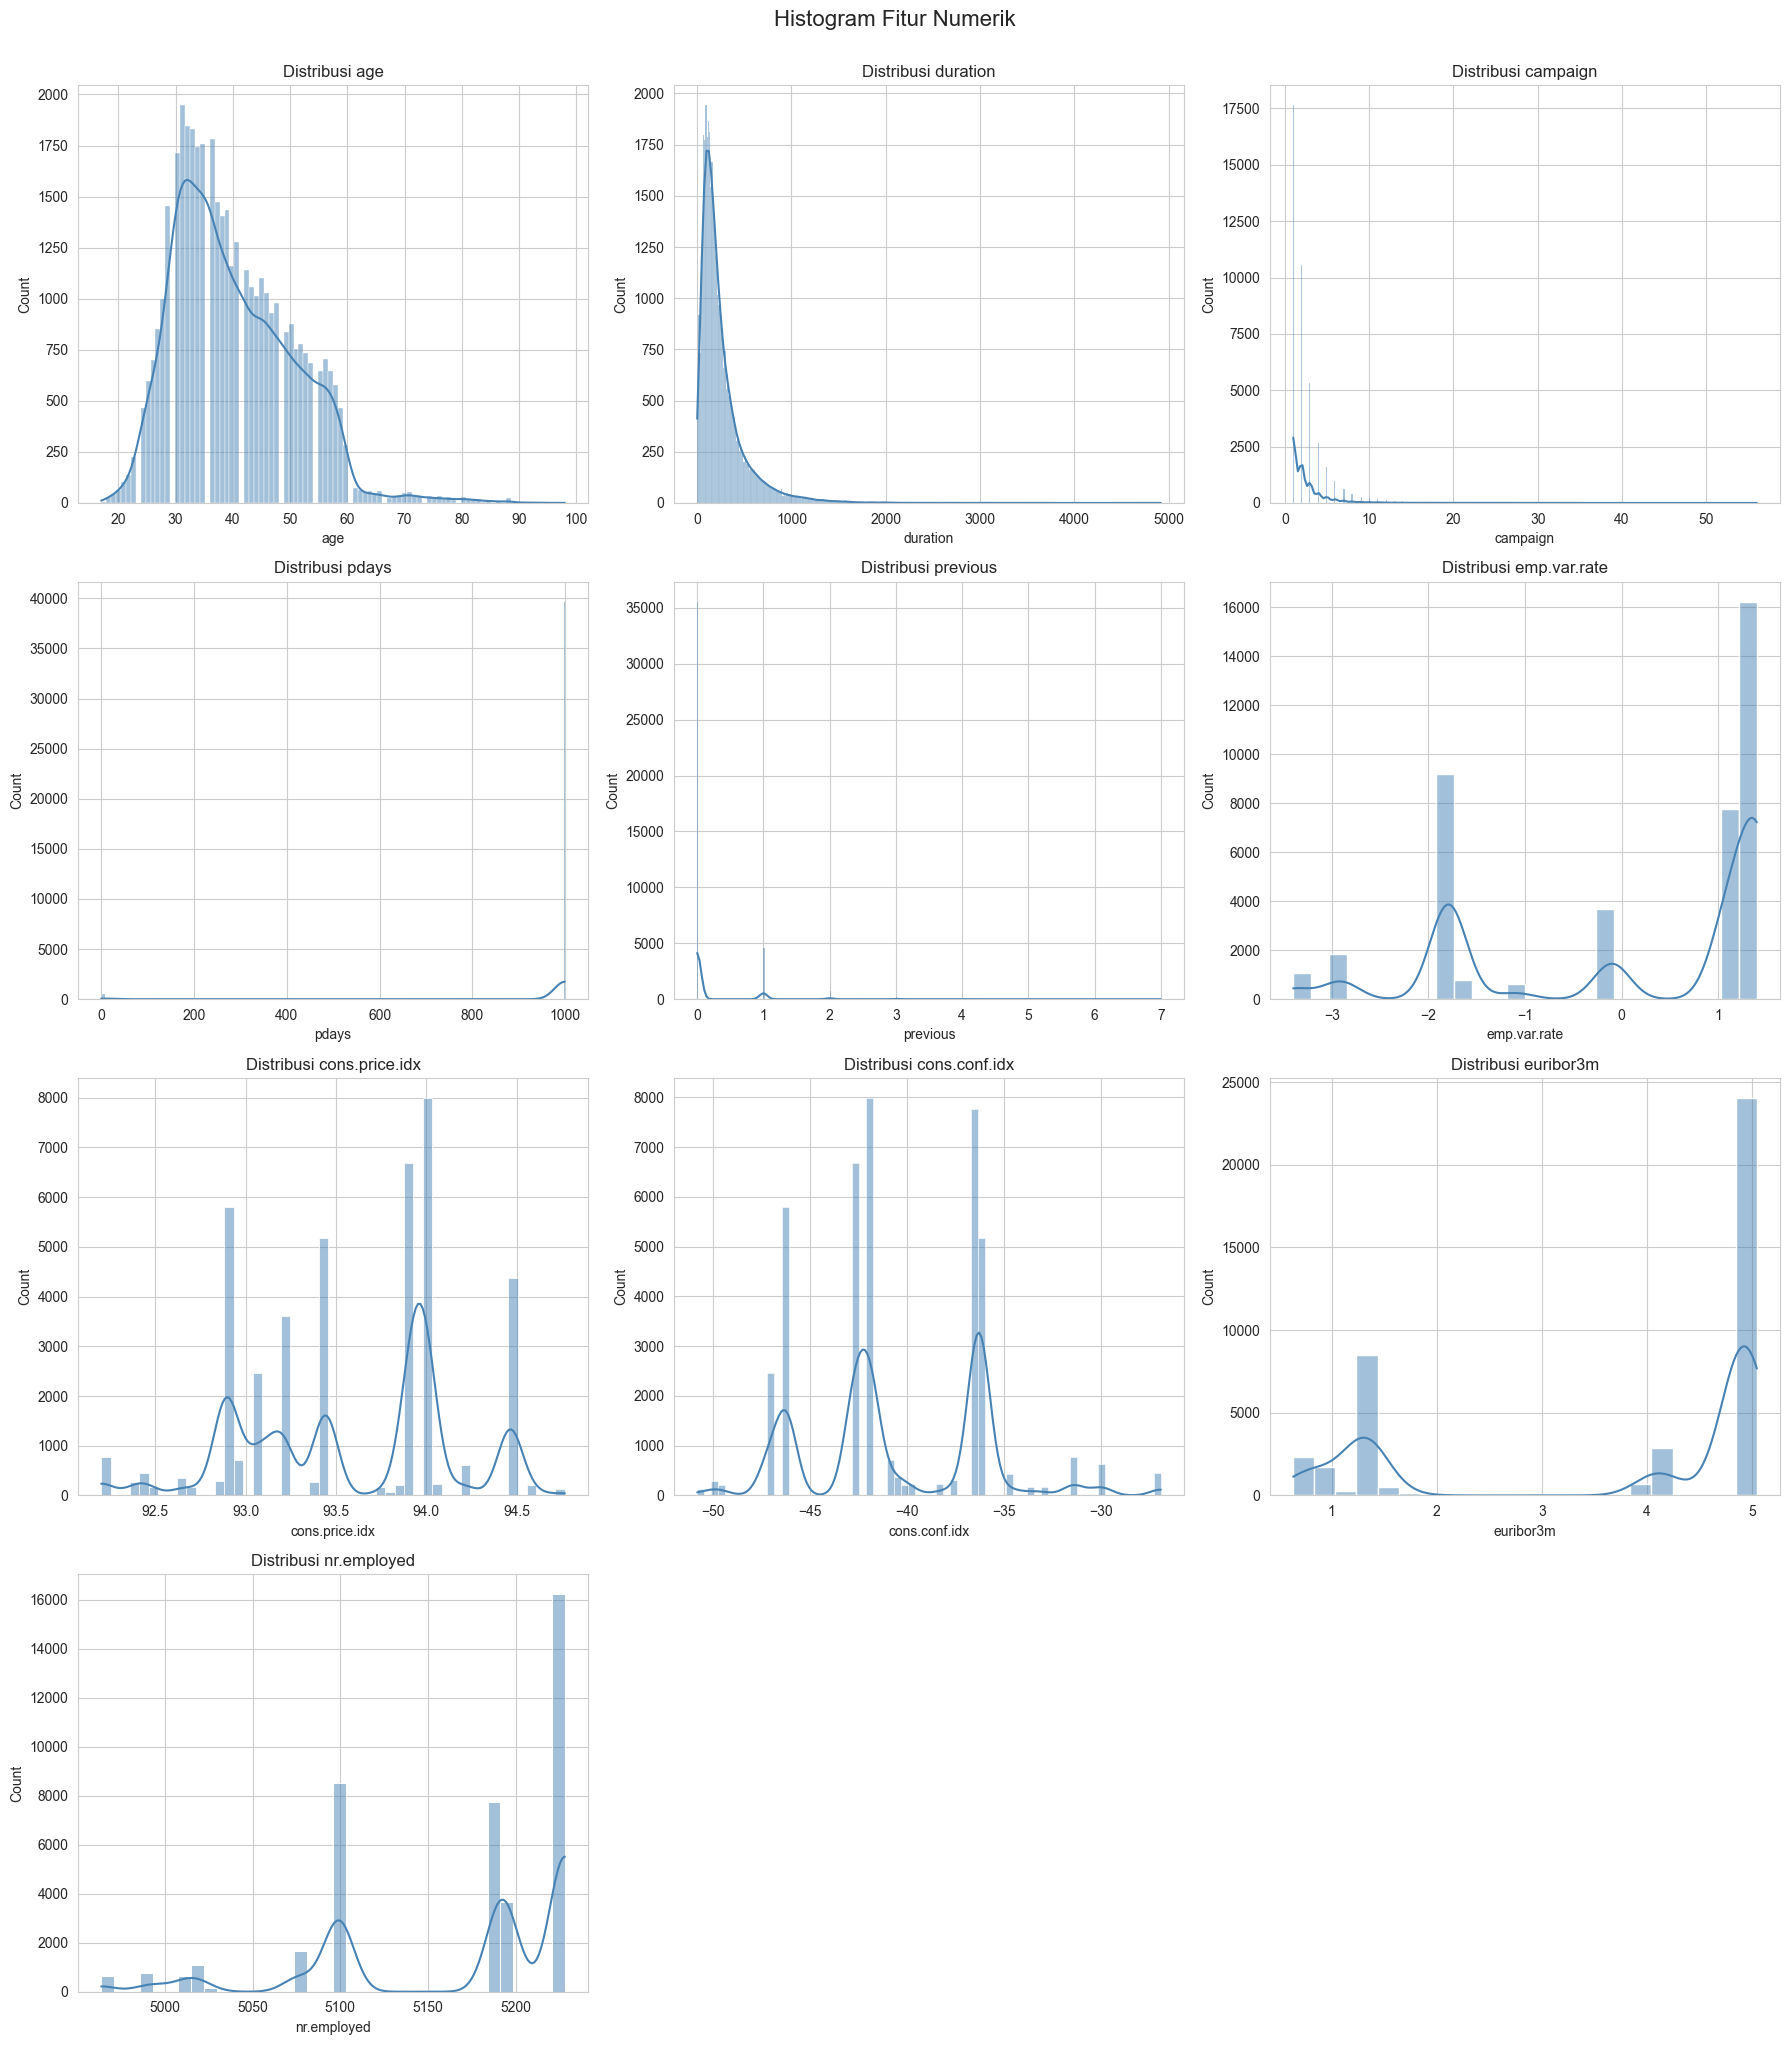

In [7]:
sns.set_style("whitegrid")

n_cols = len(feature_numerical)
n_rows = int(np.ceil(n_cols / 3))

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_numerical):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')

# Matikan axes kosong sisa (kalau jumlah fitur tidak pas kelipatan 3)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Histogram Fitur Numerik', y=1.02, fontsize=16)
plt.show()

####b. Boxplot untuk deteksi outlier

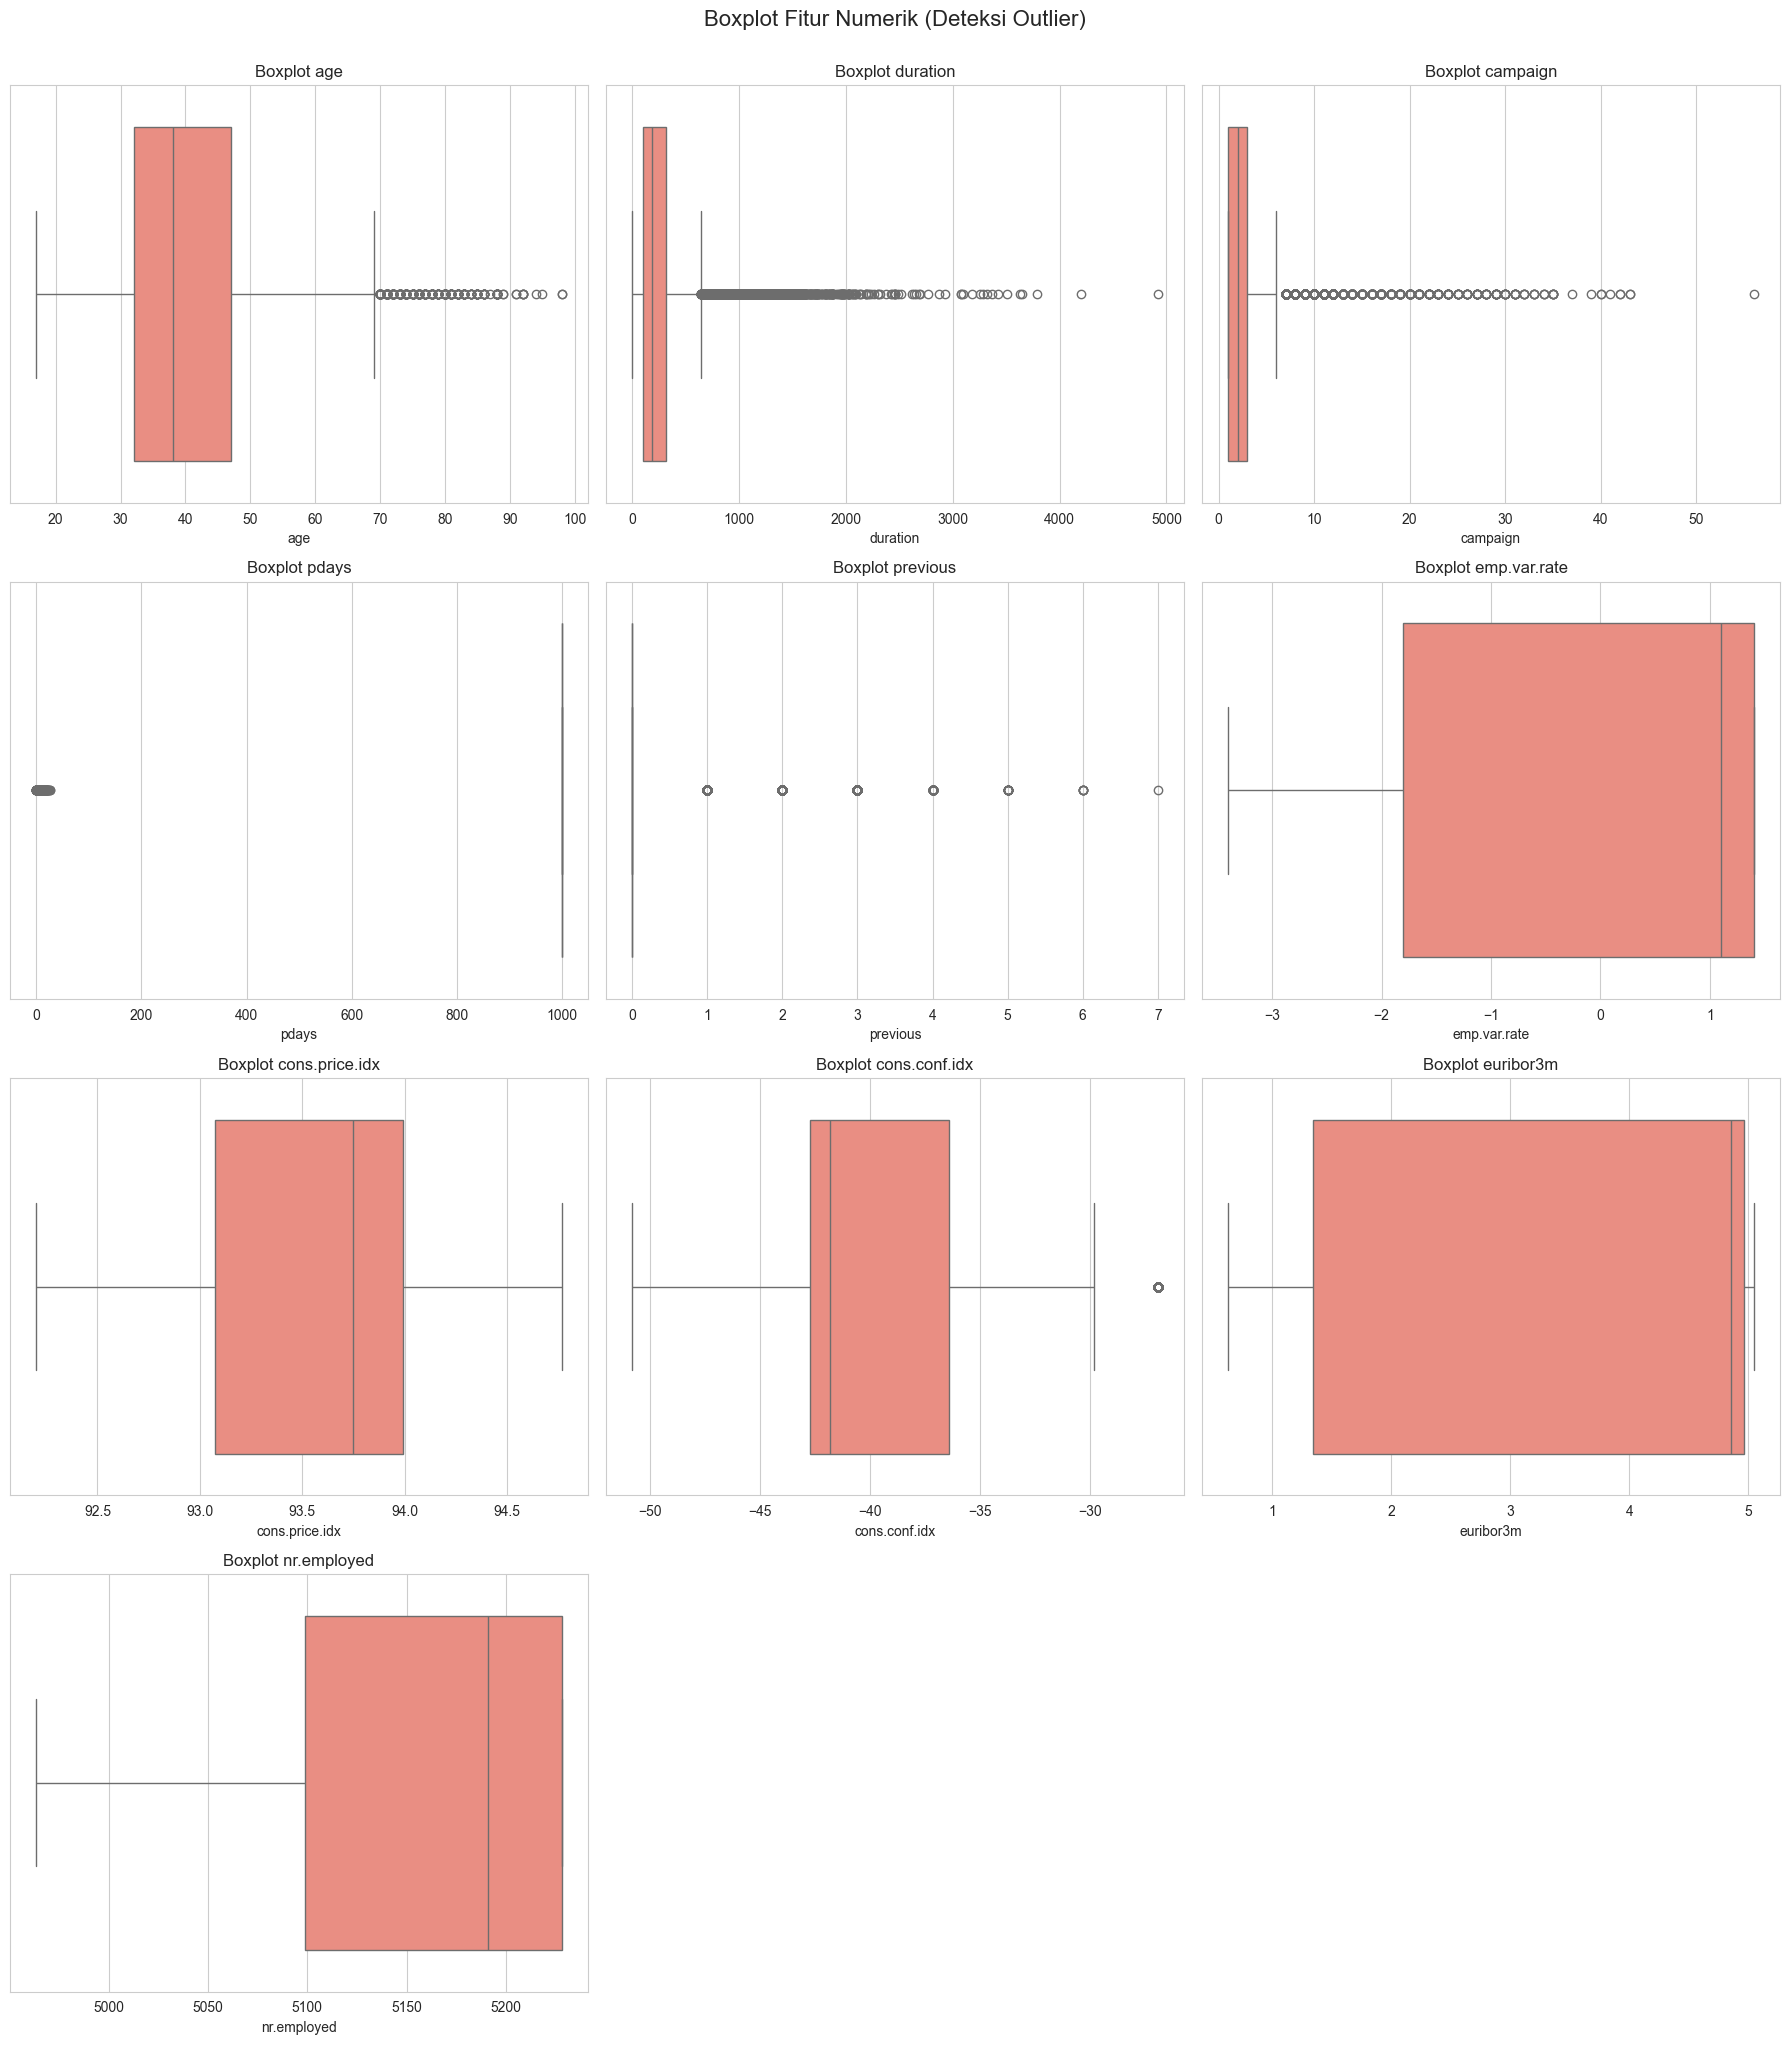

In [8]:
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(feature_numerical):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot {col}')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', y=1.02, fontsize=16)
plt.show()


####c. QQ-plot untuk cek normalitas distribusi

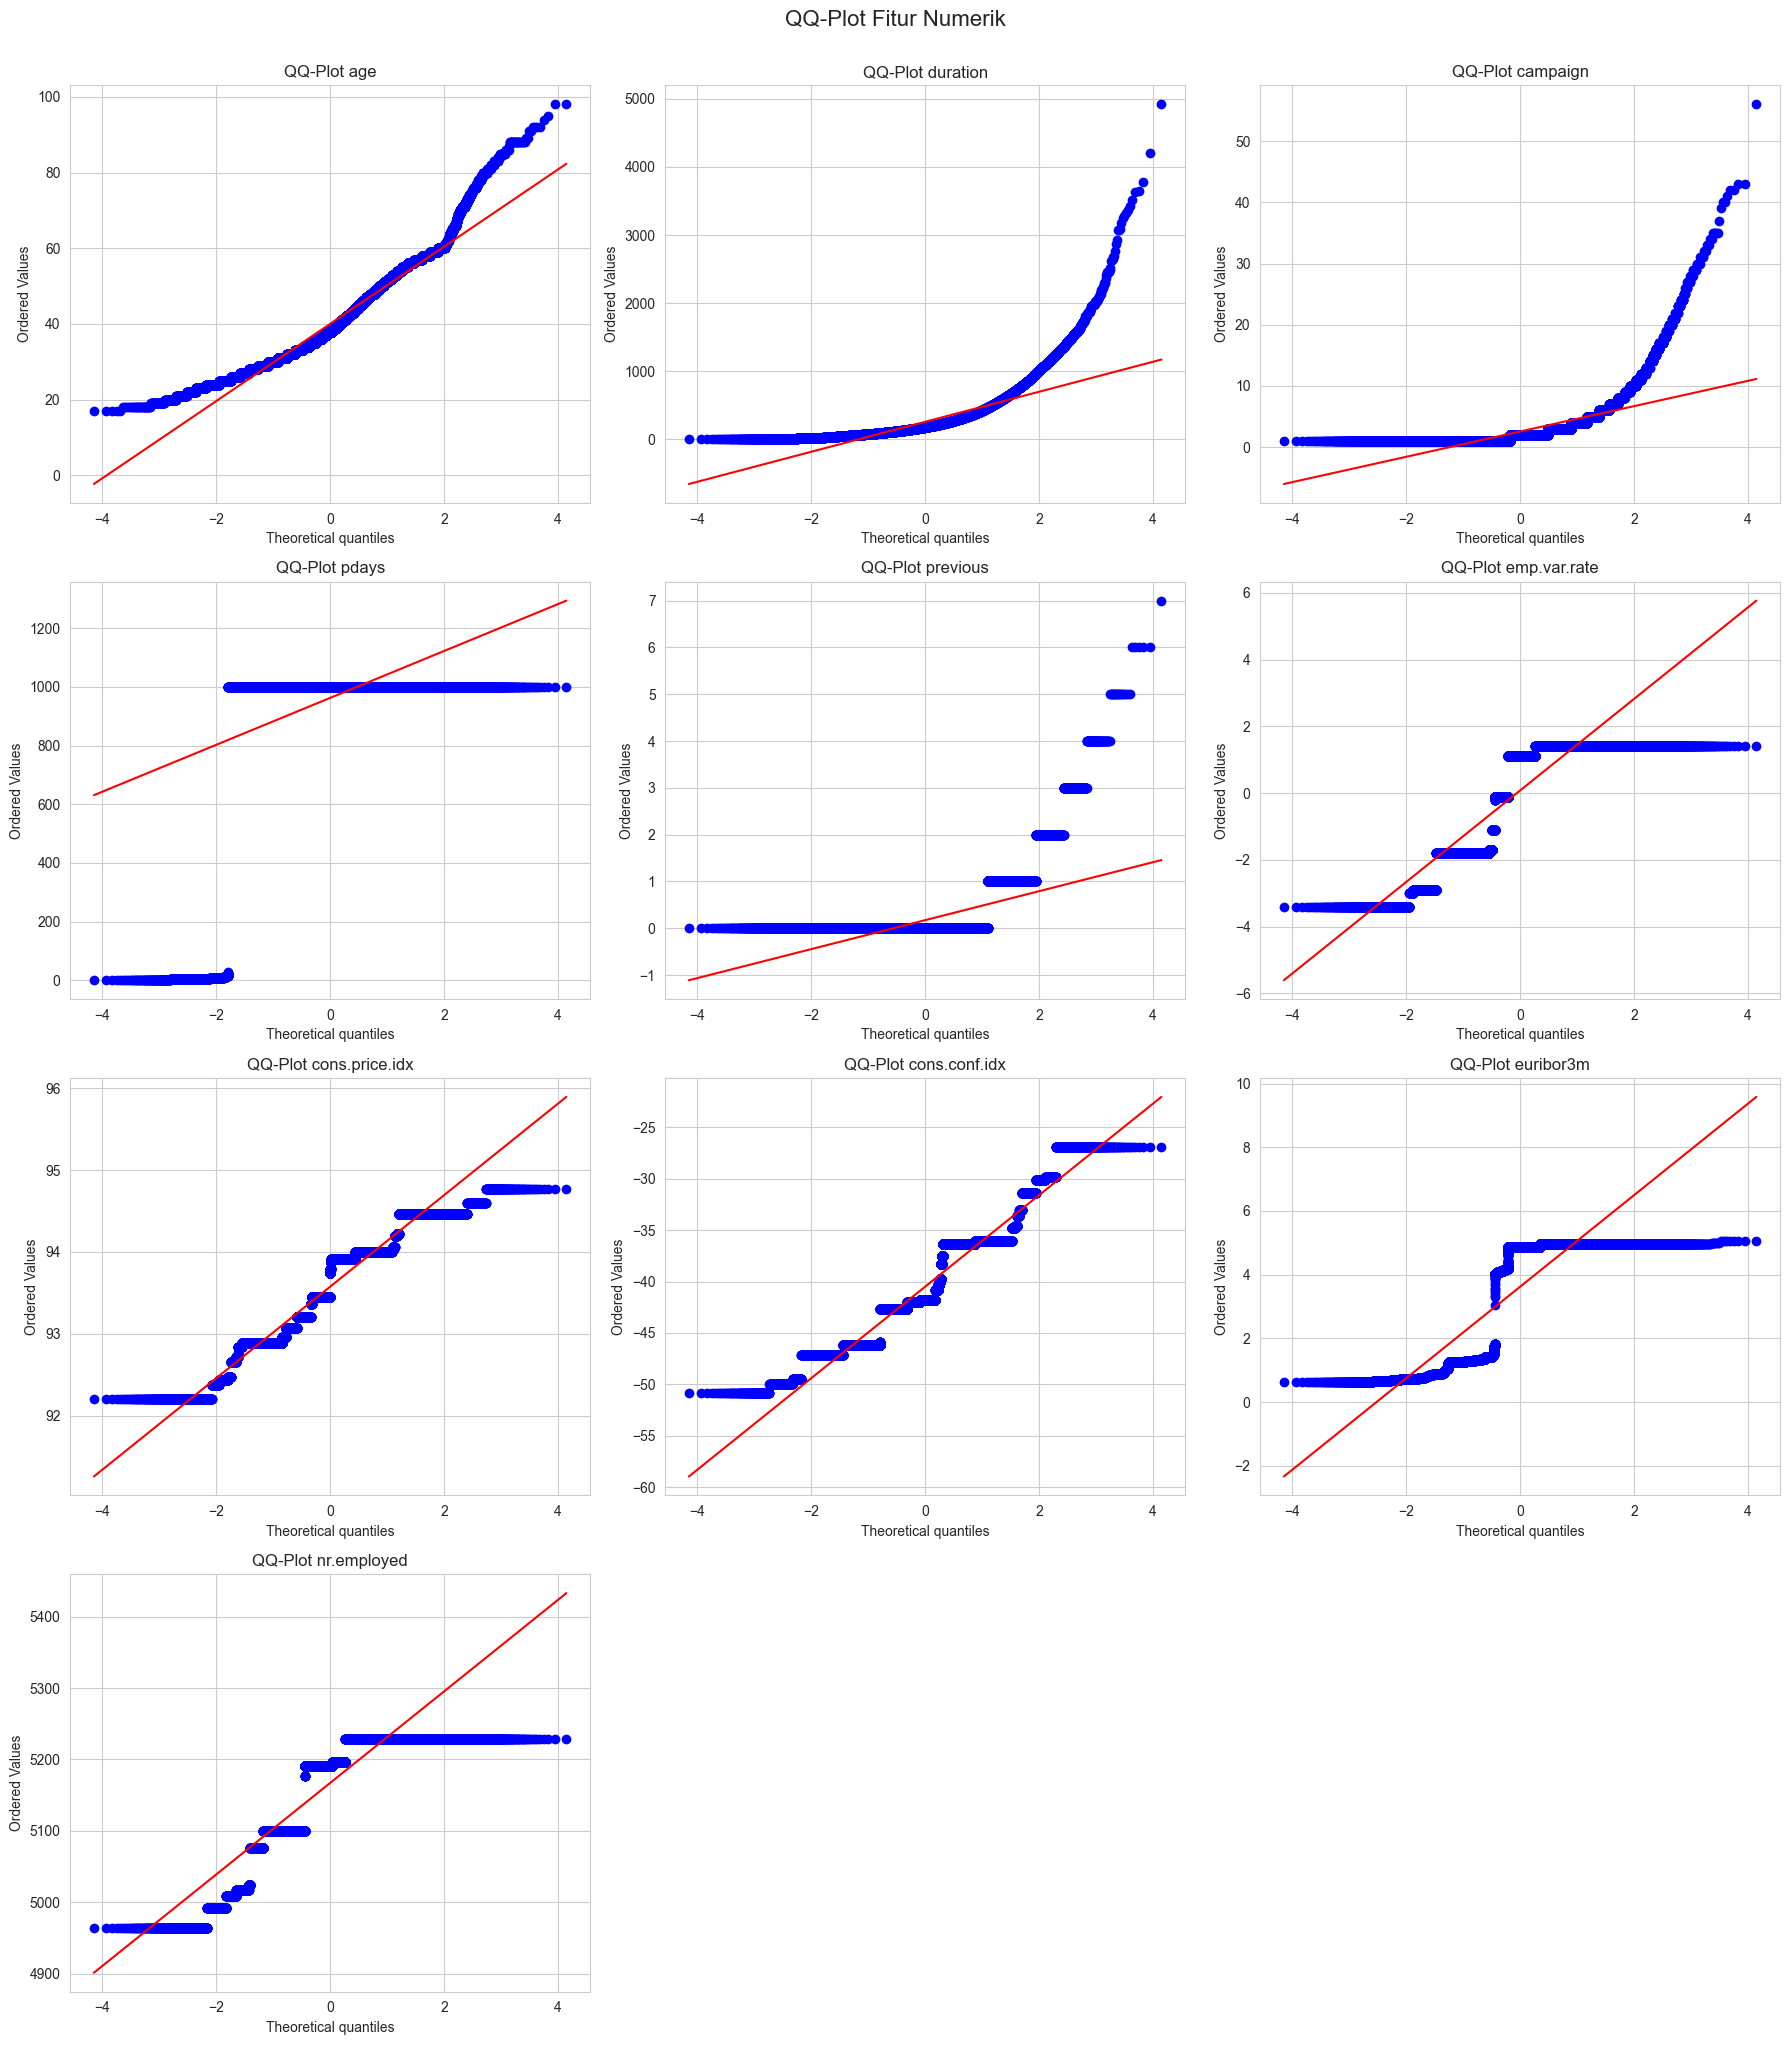

In [9]:
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(feature_numerical):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ-Plot {col}')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.suptitle('QQ-Plot Fitur Numerik', y=1.02, fontsize=16)
plt.show()

**Insight**

- duration, campaign, previous sangat right-skewed (mean jauh di atas median, contoh: duration mean=258 vs median=180) → berpotensi banyak outlier di boxplot, dan QQ-plot akan menunjukkan penyimpangan besar dari garis normal di ujung kanan.

- pdays: 999 mendominasi (39.673 dari 41.188 baris = 96,3%). Ini bukan outlier biasa, tapi sentinel value yang artinya "belum pernah dihubungi sebelumnya". Histogram akan terlihat aneh (satu batang raksasa di 999) — perlu ditangani khusus di preprocessing, bukan dianggap outlier numerik biasa.

- age relatif mendekati normal tapi tetap ada ekor kanan (usia lansia).

- emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed adalah indikator makroekonomi → sifatnya lebih diskrit/berulang (bukan kontinu murni), karena nilainya sama untuk banyak nasabah yang dikontak di periode sama.

###2. Data Correlation (Nominal & Ratio Scale)

####a. Korelasi antar fitur numerik (Pearson - ratio/interval scale)

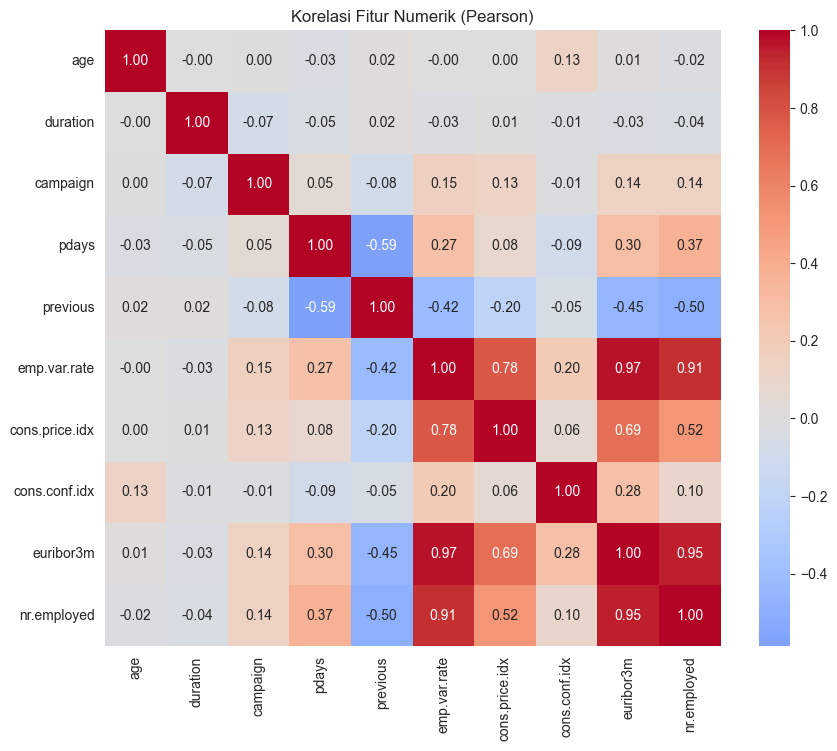

In [10]:
plt.figure(figsize=(10, 8))
corr_numerical = df[feature_numerical].corr(method='pearson')
sns.heatmap(corr_numerical, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Korelasi Fitur Numerik (Pearson)')
plt.show()


####b.Korelasi antar fitur kategorikal (Nominal - Cramér's V)

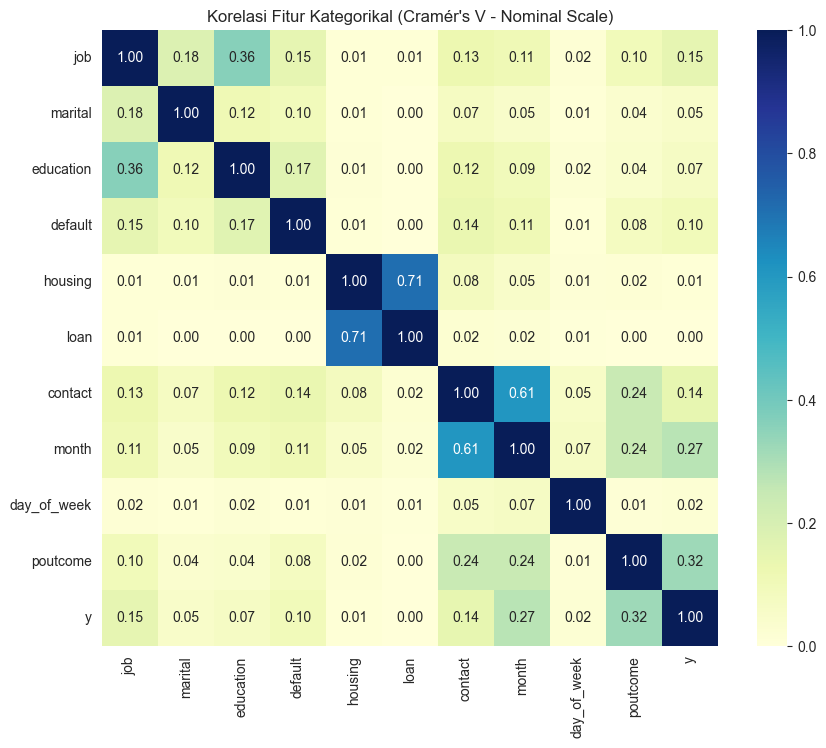

In [11]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = list(feature_categorical)
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='YlGnBu', square=True)
plt.title("Korelasi Fitur Kategorikal (Cramér's V - Nominal Scale)")
plt.show()

####c. Korelasi fitur numerik terhadap target (y)

In [12]:
df['y_binary'] = df['y'].map({'no': 0, 'yes': 1})
corr_target = df[feature_numerical].corrwith(df['y_binary']).sort_values(ascending=False)
print("Korelasi fitur numerik terhadap target (y):")
print(corr_target)

Korelasi fitur numerik terhadap target (y):
duration          0.405274
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
dtype: float64


***Insight:***

- Fitur makroekonomi (emp.var.rate, euribor3m, nr.employed, cons.price.idx) biasanya berkorelasi sangat tinggi satu sama lain (multikolinearitas) karena semuanya mencerminkan kondisi ekonomi periode yang sama → perlu diwaspadai kalau nanti masuk ke model linear (bisa dipertimbangkan drop salah satu / gunakan PCA).

- pdays dan previous biasanya berkorelasi kuat (logis: kalau previous=0 maka pdays=999).

- poutcome, contact, dan month sering menunjukkan asosiasi (Cramér's V) yang cukup tinggi terhadap target karena berkaitan dengan strategi campaign.

- duration biasanya fitur numerik dengan korelasi paling kuat ke target — tapi ini fitur "bocor" (data leakage), karena durasi telepon baru diketahui setelah panggilan selesai. Untuk model prediktif real-world, fitur ini lazim di-drop.

###3. Data Cardinality (Unique Count Fitur Kategorikal)

In [13]:
cardinality = pd.DataFrame({
    'n_unique': df[feature_categorical].nunique(),
    'unique_values': [df[c].unique().tolist() for c in feature_categorical]
}).sort_values('n_unique', ascending=False)

print(cardinality)

             n_unique                                      unique_values
job                12  [housemaid, services, admin., blue-collar, tec...
month              10  [may, jun, jul, aug, oct, nov, dec, mar, apr, ...
education           8  [basic.4y, high.school, basic.6y, basic.9y, pr...
day_of_week         5                          [mon, tue, wed, thu, fri]
marital             4               [married, single, divorced, unknown]
default             3                                 [no, unknown, yes]
housing             3                                 [no, yes, unknown]
loan                3                                 [no, yes, unknown]
poutcome            3                    [nonexistent, failure, success]
contact             2                              [telephone, cellular]
y                   2                                          [no, yes]


***Insight :***
| Fitur | Jumlah Unique | Keterangan |
|---|---:|---|
| `job` | 12 | Termasuk kategori `unknown` |
| `education` | 8 | Termasuk `unknown`; memiliki tingkatan (`basic.4y` / `basic.6y` / `basic.9y`) → bersifat ordinal dan dapat di-encode berdasarkan urutan |
| `month` | 10 | Tidak terdapat Januari (`jan`) dan Februari (`feb`) → terdapat potensi bias musiman pada data |
| `marital` | 3 | Low cardinality |
| `default` | 3 | Low cardinality |
| `housing` | 3 | Low cardinality |
| `loan` | 3 | Low cardinality |
| `poutcome` | 3 | Low cardinality |
| `contact` | 2 | Binary |
| `y` | 2 | Binary / target variable |
| `day_of_week` | 5 | Hanya mencakup Senin–Jumat |

→ Semua fitur kategorikal low-to-medium cardinality, aman untuk One-Hot Encoding (kecuali education yang lebih cocok Ordinal Encoding).

###4. Missing Value, Outlier, Anomali, Duplikat

##### a. Missing value eksplisit (NaN)

In [14]:
print("Missing value (NaN) per kolom:")
print(df.isnull().sum())

Missing value (NaN) per kolom:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
y_binary          0
dtype: int64


####b. 'unknown' sebagai missing value tersembunyi

In [15]:
print("\nJumlah 'unknown' per kolom kategorikal:")
for col in feature_categorical:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} ({n_unknown/len(df)*100:.2f}%)")


Jumlah 'unknown' per kolom kategorikal:
job: 330 (0.80%)
marital: 80 (0.19%)
education: 1731 (4.20%)
default: 8597 (20.87%)
housing: 990 (2.40%)
loan: 990 (2.40%)


####c. Duplikat

In [16]:
print(f"\nJumlah baris duplikat penuh: {df.duplicated().sum()}")
display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))


Jumlah baris duplikat penuh: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_binary
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no,0
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no,0
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,0
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,0
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,0
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,0
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no,0
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no,0


#### d. Outlier via IQR method

In [17]:
print("\nJumlah outlier (IQR method) per kolom numerik:")
for col in feature_numerical:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outlier} outlier ({n_outlier/len(df)*100:.2f}%)")


Jumlah outlier (IQR method) per kolom numerik:
age: 469 outlier (1.14%)
duration: 2963 outlier (7.19%)
campaign: 2406 outlier (5.84%)
pdays: 1515 outlier (3.68%)
previous: 5625 outlier (13.66%)
emp.var.rate: 0 outlier (0.00%)
cons.price.idx: 0 outlier (0.00%)
cons.conf.idx: 447 outlier (1.09%)
euribor3m: 0 outlier (0.00%)
nr.employed: 0 outlier (0.00%)


####e. Anomali spesifik pdays

In [18]:
print(f"\npdays = 999 (belum pernah dikontak): {(df['pdays']==999).sum()} baris ({(df['pdays']==999).mean()*100:.1f}%)")


pdays = 999 (belum pernah dikontak): 39673 baris (96.3%)


***Insight : ***

a. Tidak ada NaN eksplisit — tapi ada missing tersembunyi berupa "unknown" di 6 kolom kategorikal:

- default: 20.87% unknown ⚠️ (cukup besar, hati-hati)
- education: 4.20%
- housing & loan: 2.40% masing-masing
- job: 0.80%
- marital: 0.19%


b. Duplikat: 12 baris persis sama di semua kolom → perlu dihapus.

c. Outlier (metode IQR) diperkirakan cukup banyak di duration, campaign, previous, age karena sifat distribusinya yang skewed — namun untuk kasus marketing campaign, outlier ini kemungkinan bukan error, melainkan variasi bisnis yang valid (misal nasabah lama ditelepon = durasi telepon lama), jadi tidak otomatis dihapus, cukup di-cap/transform.

d. pdays=999 bukan outlier, tapi placeholder untuk "belum pernah dihubungi" (96,3% data) → harus ditangani sebagai kategori/flag terpisah, bukan angka kontinu biasa.

e. Target y imbalanced: 88,7% "no" vs 11,3% "yes" → penting dicatat untuk tahap modeling nanti (perlu teknik resampling/class-weight).

## D. PREPROCESSING

### 1. Fill Missing Value

In [37]:
df_clean = df.copy()

# 'unknown' diperlakukan sebagai missing value, diisi dengan modus per kolom
# for col in ['job', 'marital', 'education', 'default', 'housing', 'loan']:
#     mode_val = df_clean.loc[df_clean[col] != 'unknown', col].mode()[0]
#     n_before = (df_clean[col] == 'unknown').sum()
#     df_clean[col] = df_clean[col].replace('unknown', mode_val)
#     print(f"{col}: {n_before} 'unknown' diisi dengan modus '{mode_val}'")

***Insight:***

Karena tidak ada NaN eksplisit, strategi imputasi difokuskan pada "unknown". Digunakan modus (nilai paling sering muncul) karena semua fitur ini nominal/ordinal. Khusus default (20,9% unknown), alternatif lain yang lebih aman adalah mempertahankan "unknown" sebagai kategori tersendiri (bukan diimput), karena proporsinya besar dan kemungkinan punya makna bisnis (nasabah menyembunyikan status kredit macet). Silakan sesuaikan sesuai tujuan analisis — saya beri opsi alternatif di bawah:

###2. Casting Data Type

In [38]:
# Kolom ordinal -> category dengan urutan eksplisit
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                    'high.school', 'professional.course', 'university.degree']
df_clean['education'] = pd.Categorical(df_clean['education'], categories=education_order, ordered=True)

# Kolom nominal -> category
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                 'contact', 'month', 'day_of_week', 'poutcome', 'y']
for col in nominal_cols:
    df_clean[col] = df_clean[col].astype('category')

# Kolom numerik -> pastikan tipe sesuai
int_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']
for col in int_cols:
    df_clean[col] = df_clean[col].astype('int64')

float_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
for col in float_cols:
    df_clean[col] = df_clean[col].astype('float64')

print(df_clean.dtypes)

age                  int64
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
duration             int64
campaign             int64
pdays                int64
previous             int64
poutcome          category
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m          float64
nr.employed        float64
y                 category
y_binary             int64
dtype: object


***Insight:***

education di-casting sebagai ordered category karena punya tingkatan jelas (SD → S1), sehingga nanti bisa di-encode sebagai angka urut (Ordinal Encoding) alih-alih One-Hot — ini menjaga informasi urutan yang bermakna.

###3. Inconsistent Variable

In [39]:
# Cek konsistensi nilai antar kolom terkait
print("Cek konsistensi pdays vs previous vs poutcome:")
print(pd.crosstab(df_clean['pdays']==999, df_clean['poutcome']))

# Standarisasi nama kolom (titik -> underscore, biar konsisten & mudah diakses)
df_clean.columns = df_clean.columns.str.replace('.', '_', regex=False)

# Cek konsistensi kapitalisasi/spasi pada seluruh kolom object/category
for col in df_clean.select_dtypes(include='category').columns:
    print(col, ':', sorted(df_clean[col].unique().astype(str)))

Cek konsistensi pdays vs previous vs poutcome:
poutcome  failure  nonexistent  success
pdays                                  
False         142            0     1373
True         4110        35563        0
job : [np.str_('admin.'), np.str_('blue-collar'), np.str_('entrepreneur'), np.str_('housemaid'), np.str_('management'), np.str_('retired'), np.str_('self-employed'), np.str_('services'), np.str_('student'), np.str_('technician'), np.str_('unemployed'), np.str_('unknown')]
marital : [np.str_('divorced'), np.str_('married'), np.str_('single'), np.str_('unknown')]
education : ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', np.str_('nan'), 'professional.course', 'university.degree']
default : [np.str_('no'), np.str_('unknown'), np.str_('yes')]
housing : [np.str_('no'), np.str_('unknown'), np.str_('yes')]
loan : [np.str_('no'), np.str_('unknown'), np.str_('yes')]
contact : [np.str_('cellular'), np.str_('telephone')]
month : [np.str_('apr'), np.str_('aug'), np.str_('dec'

***Insight:***

 Nama kolom seperti emp.var.rate, cons.price.idx mengandung titik (.) yang berisiko error saat diakses via df.emp.var.rate (dianggap atribut bertingkat) → diseragamkan jadi underscore (emp_var_rate). Dari cek silang, pdays=999 selalu konsisten dengan poutcome='nonexistent' — tidak ditemukan baris yang aneh (misal pdays≠999 tapi poutcome='nonexistent'), artinya data cukup konsisten secara logika bisnis.

###4. Remove Duplicate

In [40]:
print(f"Jumlah baris sebelum hapus duplikat: {len(df_clean)}")
df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Jumlah baris setelah hapus duplikat: {len(df_clean)}")

Jumlah baris sebelum hapus duplikat: 41188
Jumlah baris setelah hapus duplikat: 41176


***Insight:***

12 baris duplikat penuh dihapus (0,03% dari total data) — dampaknya minimal terhadap distribusi data, tapi tetap penting dihapus agar tidak menggandakan bobot observasi tertentu saat training model.

###5. Feature Engineering

In [41]:
#a. Flag apakah nasabah pernah dikontak sebelumnya (dari pdays)
df_clean['was_contacted_before'] = np.where(df_clean['pdays'] == 999, 0, 1)

#b. Ganti nilai sentinel 999 pada pdays jadi -1 supaya tidak merusak skala numerik
#     (karena 999 bukan "962 hari" sungguhan, hanya penanda "tidak pernah")
# kalo diganti 0 bisa nambah bias, karena 0 = "baru saja dikontak" (bukan "belum pernah")
df_clean['pdays_clean'] = np.where(df_clean['pdays'] == 999, -1, df_clean['pdays'])

#c. Age binning -> kelompok usia (kategori lebih interpretable utk campaign)
df_clean['age_group'] = pd.cut(df_clean['age'],
                                 bins=[0, 25, 35, 45, 55, 65, 100],
                                 labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'])

#d. Flag pernah punya campaign sebelumnya (previous > 0)
df_clean['has_previous_contact'] = (df_clean['previous'] > 0).astype(int)

#e. Kelompokkan bulan ke kuartal (opsional, mengurangi cardinality musiman)
month_to_quarter = {'jan':'Q1','feb':'Q1','mar':'Q1','apr':'Q2','may':'Q2','jun':'Q2',
                     'jul':'Q3','aug':'Q3','sep':'Q3','oct':'Q4','nov':'Q4','dec':'Q4'}
df_clean['quarter'] = df_clean['month'].map(month_to_quarter)

#f. Encode target jadi biner
df_clean['y'] = df_clean['y'].map({'no': 0, 'yes': 1}).astype('int64')

df_clean.head()
# df_clean.save

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,y_binary,was_contacted_before,pdays_clean,age_group,has_previous_contact,quarter
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,55-64,0,Q2
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,55-64,0,Q2
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,35-44,0,Q2
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,35-44,0,Q2
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,-1,55-64,0,Q2


***Insight:***

 Fitur baru dibuat berdasarkan temuan EDA:
- was_contacted_before mengubah info sentinel 999 menjadi flag biner yang lebih bermakna secara statistik.
- pdays_clean menghindari 999 merusak skala/korelasi saat dipakai model numerik langsung.
- age_group & quarter menyederhanakan fitur kontinu/kardinalitas tinggi jadi kategori bisnis yang lebih interpretable untuk analisis campaign.
- Target y di-encode biner (0/1) agar siap dipakai untuk modeling klasifikasi.

## E. Methodology (Data Analytics)

Bagian ini akan menjawab problem statement secara deskriptif: Nasabah dengan karakteristik apa, pada waktu dan kanal apa, serta pada panggila keberapa yang paling layak diprioritaskan bank agar kampanye telemarketing menjadi efisien?

Analisis pada bagian pada bagian ini disusun dengan mnejawab 5W-1H supaya setiap temuan langsung terhubung ke keputusan operasional tim telemarketing

Dua paradigma analisis akan dipakai dalam bagian tersebut:
1. Analisis deskriptif: menceritakan pola melalui statistik ringkas dan visualisasi.
2. Analisis inferensial: menguji apakah pola tersebut signifikan secara statistik (dengan chi-square, Cramer's V, Mann-Whitney U, two-proportion z-test), sehingga rekomendasi tidak dibangun di atas perbedaan yang sebenarnya kebetulan sampel.

### a. Seberapa Besar Masalahnya?

Sebelum mencari segmen terbaik, besarnya masalah harus dikulik terlebih dahulu sebagai pembanding seluruh rekomendasi di bagian akhir. Semua analisis di bagian tersebut akan menggunakan `df_clean` dengan empat acuan, yaitu jumlah nasabah dikontak, jumlah deposan, baseline conversion rate, dan total panggilan. Keempat acuan ini akan dipakai secara berulang sebagai pembanding pada semua grafik dan uji statistik di sub-bab selanjutnya.

In [42]:
n_nasabah = len(df_clean)
n_deposan = df_clean['y'].sum()
baseline_rate = df_clean['y'].mean() * 100 # dalam persen
total_call = df_clean['campaign'].sum()

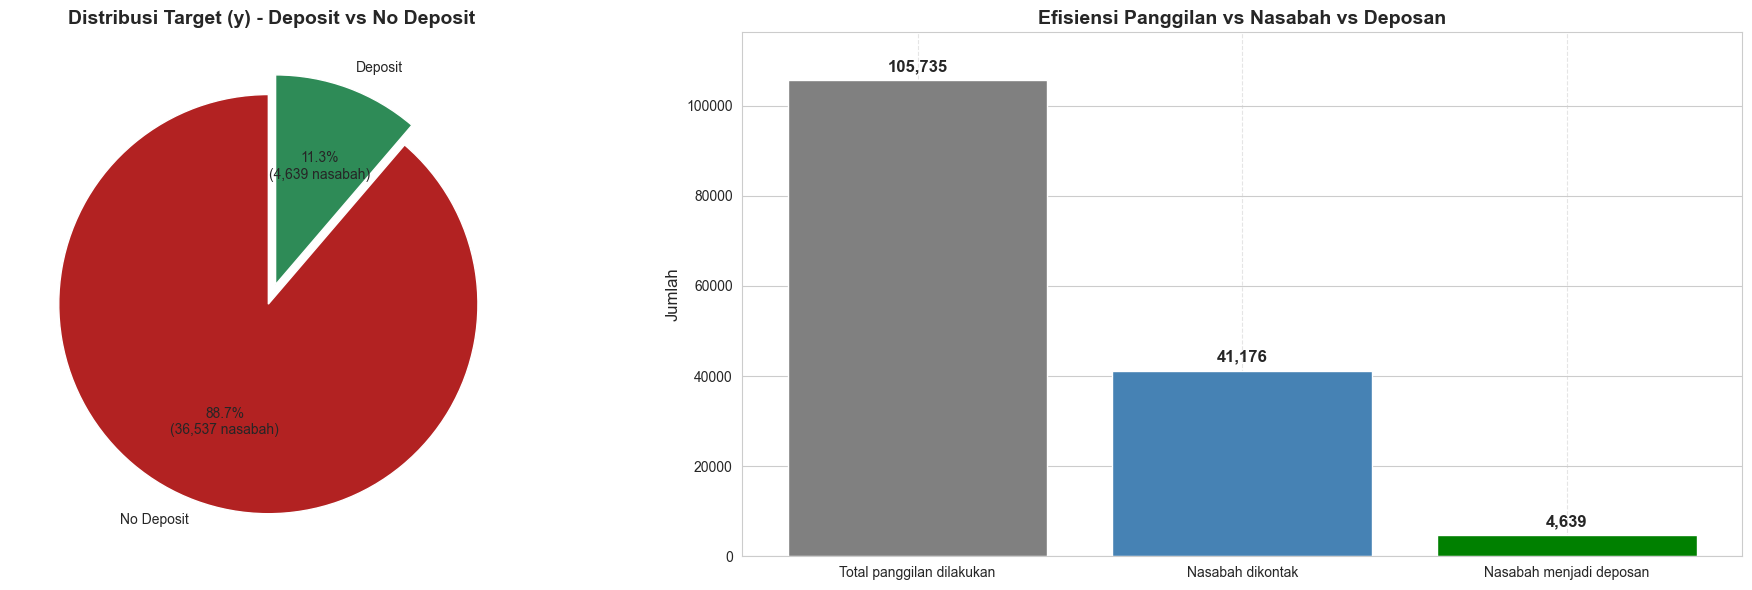

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].pie(df_clean['y'].value_counts(), 
            labels=['No Deposit', 'Deposit'], 
            autopct=lambda p: f'{p:.1f}%\n({p*n_nasabah/100:,.0f} nasabah)', 
            startangle=90, 
            colors=['firebrick', 'seagreen'],
            explode=(0.05, 0.05))
axes[0].set_title("Distribusi Target (y) - Deposit vs No Deposit", fontsize=14, weight="bold")

efisiensi_call = pd.Series({
    "Total panggilan dilakukan": total_call,
    "Nasabah dikontak": n_nasabah,
    "Nasabah menjadi deposan": n_deposan,
})
bar = axes[1].bar(efisiensi_call.index, efisiensi_call.values, color=['grey', 'steelblue', 'green'])
for b, v in zip(bar, efisiensi_call.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 2000, f"{v:,}", ha='center', fontsize=12, weight="bold")
axes[1].set_title("Efisiensi Panggilan vs Nasabah vs Deposan", fontsize=14, weight="bold")
axes[1].set_ylabel("Jumlah", fontsize=12)
axes[1].set_ylim(0, total_call*1.1)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

In [44]:
# Detail
print(f"Jumlah nasabah                              : {n_nasabah:,}")
print(f"Jumlah deposan                              : {n_deposan:,}")
print(f"Baseline conversion rate                    : {baseline_rate:.2f}%")
print(f"Total panggilan dilakukan                   : {total_call:,} kali")
print(f"Rata-rata panggilan per nasabah             : {total_call/n_nasabah:.2f} panggilan/nasabah")
print(f"Pangilan per deposan                        : {total_call/n_deposan:.2f} kali/deposan")
print(f"Panggilan yang tidak menghasilkan deposan   : {total_call - n_deposan:,} ({(total_call - n_deposan)/total_call*100:.2f}%)")

Jumlah nasabah                              : 41,176
Jumlah deposan                              : 4,639
Baseline conversion rate                    : 11.27%
Total panggilan dilakukan                   : 105,735 kali
Rata-rata panggilan per nasabah             : 2.57 panggilan/nasabah
Pangilan per deposan                        : 22.79 kali/deposan
Panggilan yang tidak menghasilkan deposan   : 101,096 (95.61%)


#### **INSIGHT: WHAT AND HOW BIG**

Dari total 41.176 nasabah yang dihubungi, hanya 4.639 nasabah (11,27%) yang akhirnya menempatkan deposito. Karena satu nasabah rata-rata ditelpon sebanyak 2-3 kali (dihitung secara mutlak), total panggilan sebenarnya adalah 105.735 panggilan. Artinya, bank perlu sekitar 23 panggilan untuk mendapatkan 1 deposan, dan 95,6% panggilan tidak menghasilkan deposito sama sekali.

Angka 22,8 panggilan/deposan menjadi tumpu yang akan dipakai untuk menilai seluruh rekomendasi hasil analisis dan bagian kesimpulan. Setiap strategi baru hanya layak diadopsi jika mampu menurunkan rasi ini secara berarti.

#### b. Fitur mana yang benar-benar berpengaruh?

Sebelum mengulik ke setiap variable, seluruh fitur kategorikal diuji sekaligus terhadap target dengan menggunakan chi-square test of independence signifikansi dan Cramer's V sebagai kekuatan asosiasi. 

Chi-square test of independence digunakan karena fitur dan target sama-sama dalam bentuk kategorikal, bukan numerikal, sehingga test ini akan menjadi alat utama untuk melihat hubungan antar fitur dan target. Berikut adalah hipotesis ujinya:
- H0: fitur dan keputusan deposito tidak ada hubungan
- H1: fitur dan keputusan deposito ada hubungan
H0 akan ditolak jika p-value < 0.05.


In [51]:
feature_categorical = ['poutcome', 'month', 'job', 'contact', 'default', 'education', 'marital', 'day_of_week', 'housing', 'loan']

results = []
for col in feature_categorical:
    tabel = pd.crosstab(df_clean[col], df_clean['y'])
    chi2, p, dof, expected = chi2_contingency(tabel)  # expected = jumlah bila H0 benar
    results.append([col, tabel.shape[0], round(chi2, 2), p, dof, round(expected.min(), 1)])

test = pd.DataFrame(results, columns=['feature', 'n_categories', 'chi2_stat', 'p_value', 'dof', 'min_expected'])
test['kesimpulan'] = np.where((test['p_value'] < 0.05) , 'Tolak H0 (Ada hubungan)', 'Gagal Tolak H0 (Tidak ada hubungan)')
test = test.sort_values('p_value').reset_index(drop=True)
display(test)
print(f"Fitur yang terbukti berhubungan pada alpha 5%: {(test['p_value'] < 0.05).sum()} dari {len(test)} fitur kategorikal")

# Cek asumsi chi square: expected frequency > 5 untuk semua sel
print("\nCek asumsi chi square: expected frequency > 5 untuk semua sel")
melanggar = test.loc[test['min_expected'] < 5, 'feature'].tolist()
if not melanggar:
    print('Terpenuhi pada seluruh fitur.')
for kolom in melanggar:
    tabel   = pd.crosstab(df_clean[kolom], df_clean['y'])
    harapan = pd.DataFrame(stats.chi2_contingency(tabel)[3],
                           index=tabel.index, columns=tabel.columns)
    mini    = harapan.index[harapan.min(axis=1) < 5].tolist()      # kategori penyebabnya
    n_mini  = [int((df_clean[kolom] == m).sum()) for m in mini]
    p_awal  = test.loc[test['feature'] == kolom, 'p_value'].iloc[0]
    # uji ulang tanpa kategori bervolume sangat kecil tersebut
    ulang = df_clean[~df_clean[kolom].isin(mini)]
    chi2b, p_baru, _, harapan_baru = stats.chi2_contingency(
        pd.crosstab(ulang[kolom].astype(str), ulang['y']))
    print(f"TIDAK terpenuhi pada `{kolom}` karena penyebabnya kategori {mini} "
          f"yang hanya berisi {n_mini} baris dari {len(df_clean):,}.")
    print(f"   Diuji ulang tanpa kategori itu: p = {p_baru:.3e} (semula {p_awal:.3e}), "
          f"frekuensi harapan terkecil kini {harapan_baru.min():.1f}"
          f" -> kesimpulan tidak berubah.")

,feature,n_categories,chi2_stat,p_value,dof,min_expected,kesimpulan
0,poutcome,3,4230.14,0.000000e+00,2,154.7,Tolak H0 (Ada hubungan)
1,month,10,3103.03,0.000000e+00,9,20.5,Tolak H0 (Ada hubungan)
2,job,12,961.74,3.268412e-199,11,37.2,Tolak H0 (Ada hubungan)
3,contact,2,862.08,1.718741e-189,1,1694.6,Tolak H0 (Ada hubungan)
4,default,3,406.56,5.217541e-89,2,0.3,Tolak H0 (Ada hubungan)
5,education,7,175.80,2.646943e-35,6,2.0,Tolak H0 (Ada hubungan)
6,marital,4,122.96,1.778423e-26,3,9.0,Tolak H0 (Ada hubungan)
7,day_of_week,5,26.05,3.085755e-05,4,881.7,Tolak H0 (Ada hubungan)
8,housing,3,5.74,5.663793e-02,2,111.5,Gagal Tolak H0 (Tidak ada hubungan)
9,loan,3,1.10,5.771532e-01,2,111.5,Gagal Tolak H0 (Tidak ada hubungan)


Fitur yang terbukti berhubungan pada alpha 5%: 8 dari 10 fitur kategorikal

Cek asumsi chi square: expected frequency > 5 untuk semua sel
TIDAK terpenuhi pada `default` karena penyebabnya kategori ['yes'] yang hanya berisi [3] baris dari 41,176.
   Diuji ulang tanpa kategori itu: p = 3.719e-90 (semula 5.218e-89), frekuensi harapan terkecil kini 968.5 -> kesimpulan tidak berubah.
TIDAK terpenuhi pada `education` karena penyebabnya kategori ['illiterate'] yang hanya berisi [18] baris dari 41,176.
   Diuji ulang tanpa kategori itu: p = 1.756e-38 (semula 2.647e-35), frekuensi harapan terkecil kini 194.8 -> kesimpulan tidak berubah.


Hasilnya, 8 dari 10 fitur menolak H0 yang artinya terbukti mayoritas fitur ada hunungan dengan keputusan deposito. Hanya *housing* dan *loan* yang gagal.

Chi-square menyaratkan frekuensi expectation minimal 5 di setiap sel contingency tablenya. Syarat ini terpenuhi pada 8 fitur, tetapi dilanggar pada *default* dan *education*. Penyebabnya adalah kategori yang bervolume sangat kecil: `default = 'yes'` hanya berisi 3 baris dan `education = 'illiterate'` 18 barus dari 41.176 baris. keduanya diuji ulang tanpa kategori tersebut tetap menghasilkan hasil yang sama (*p* = 3,7 × 10⁻⁹⁰ dan *p* = 1,8 × 10⁻³⁸). Temuan ini penting untuk tahap modeling karena `default = 'yes'` terlalu kecil untuk berdiri sendiri dan sebaiknya digabung ke unknown agar tidak menghasilkan kolom one-hot yang nyaris konstan.

Daftar di atas belum bisa dipakai meilih fitur. Kolom *kesimpulan* memberi label yang persis sama: "Tolak H0 -> ada hubungan" kepada *poutcome* dan *day_on_week*, padahal nilai chi-square keduanya 4.230,1 berbanding 26,1: terpaut 162 kali lipat. Selama yang dibaca hanya p-value atau kolom kesimpulan, kedua fitur itu tampak sangat penting. 

Kenapa tidak memringkatkan mememakai nilai chi-square saja? Karena chi-square ikut membesar menginkuti dua hal yang tidak ada hubungannya dengan kuat-lemahnya asosiasi: jumlah sampel dan ukuran tabel kontingensi. Bandingkan `month` (10 kategori, dof 8, chi2 = 3103.0) dengan `contact` (2 kategori, dof 1, chi2 = 862.1), angka mentahnya tidak setara karena tabelnya beda ukuran, bukan karena hubunganya beda kuat. Sehingga, yang dibutuhkan sekarang adalah ukuran yang sudah dibagi jumlah sampel dan disesuaikan dengan ukuran tabel, sehingga seluruh fitur berdiri di skala yang sama dan bisa diperingkat. Itulah tahap kedua: **Cramer's V**

Cramer's V mengubah nilai chi-square menjadi skala 0-1 (0 = tidak ada asosiasi, 1 = asosiasi sempurna). Karena chi-square dibagi jumlah sampel, ukuran ini tidak ikut membesar hanya karena n besar. Itulah sebabnya V bisa dipakai memeringkat fitur sementara p-value tidak bisa.

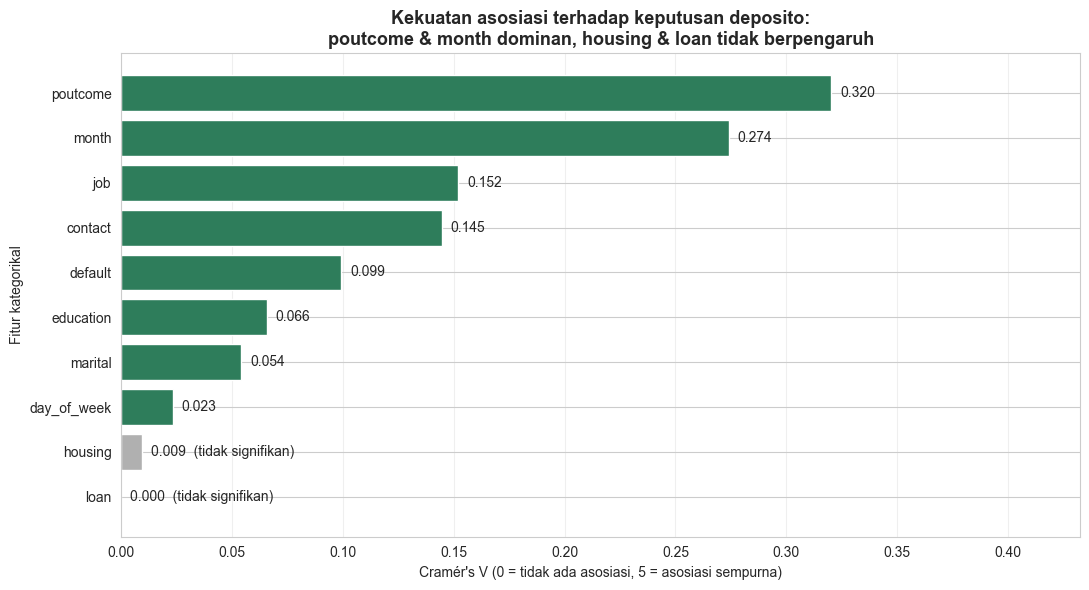

,feature,chi2_stat,p_value,cramers_v,kekuatan,kesimpulan
0,poutcome,4230.140000,0.000e+00,0.320400,kuat,Tolak H0 (Ada hubungan)
1,month,3103.030000,0.000e+00,0.274100,kuat,Tolak H0 (Ada hubungan)
2,job,961.740000,3.268e-199,0.152000,sedang,Tolak H0 (Ada hubungan)
3,contact,862.080000,1.719e-189,0.144600,sedang,Tolak H0 (Ada hubungan)
4,default,406.560000,5.218e-89,0.099100,lemah,Tolak H0 (Ada hubungan)
5,education,175.800000,2.647e-35,0.065600,lemah,Tolak H0 (Ada hubungan)
6,marital,122.960000,1.778e-26,0.054000,lemah,Tolak H0 (Ada hubungan)
7,day_of_week,26.050000,3.086e-05,0.023100,sangat lemah,Tolak H0 (Ada hubungan)
8,housing,5.740000,5.664e-02,0.009500,sangat lemah,Gagal Tolak H0 (Tidak ada hubungan)
9,loan,1.100000,5.772e-01,0.000000,sangat lemah,Gagal Tolak H0 (Tidak ada hubungan)


In [59]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

test['cramers_v'] = [round(cramers_v(df_clean[f], df_clean['y']), 4) for f in test['feature']]
test['kekuatan'] = pd.cut(test['cramers_v'], bins=[-1, .05, .10, .20, 1],
                         labels=['sangat lemah', 'lemah', 'sedang', 'kuat'])
test = test.sort_values('cramers_v', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
warna = np.where(test['p_value'] < 0.05, '#2E7D5B', '#B0B0B0')
ax.barh(test['feature'][::-1], test['cramers_v'][::-1], color=warna[::-1])
for i, (v, p) in enumerate(zip(test['cramers_v'][::-1], test['p_value'][::-1])):
    ax.text(v + .004, i, f"{v:.3f}" + ('' if p < 0.05 else '  (tidak signifikan)'),
            va='center', fontsize=10)
ax.set_xlabel("Cramér's V (0 = tidak ada asosiasi, 5 = asosiasi sempurna)")
ax.set_ylabel('Fitur kategorikal')
ax.set_xlim(0, test['cramers_v'].max() * 1.35)
ax.set_title("Kekuatan asosiasi terhadap keputusan deposito:\n"
             "poutcome & month dominan, housing & loan tidak berpengaruh",
             fontsize=13, weight='bold')
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

display(test[['feature', 'chi2_stat', 'p_value', 'cramers_v', 'kekuatan', 'kesimpulan']]
        .style.format({'p_value': '{:.3e}'}))

**INSIGHT**

Dari 10 fitur kategorikal, 8 signifikan pada alpha = 0.05 dan 2 tidak. Peringkat kekuatan asosiasi dengan Cramer's V: `poutcome` 0.320 dan `month` 0.274 (kategori kuat), disusul `job` 0.152 dan `contact` 0.145 (sedang).

Temuan negatif yang justru berguna. `housing` (V = 0,010; p = 0,057) dan `loan`
(V = 0,000; p = 0,577) tidak berhubungan dengan keputusan deposito. Ini berlawanan dengan dugaan awal bahwa nasabah dengan cicilan KPR atau pinjaman pribadi punya lebih sedikit dana menganggur. Pada n sebesar 41.176 — di mana selisih sekecil apa pun biasanya lolos uji — kedua fitur tetap gagal signifikan, sehingga kesimpulannya cukup kuat: kepemilikan kredit tidak boleh dipakai sebagai dasar segmentasi kampanye.

Mengapa dua ukuran dilaporkan bersama? `day_of_week` signifikan (*p* = 3,1 x 10⁻⁵) tetapi Cramér's V-nya hanya **0,023** — praktis tanpa nilai bisnis. Ini contoh klasik signifikan secara statistik tetapi tidak berarti secara praktis, yang hanya terlihat bila ukuran efek ikut dilaporkan. Guideline secara khusus mengingatkan agar tingkat signifikansi tidak digeneralisasi tanpa pertimbangan, dan kasus ini memperlihatkan alasannya.

**Rekomendasi (Action)** 

Prioritaskan `poutcome`, `month`, `job`, dan `contact` sebagai tulang punggung aturan penargetan; keluarkan `housing` dan `loan` dari kriteria segmentasi manual. Untuk tahap modeling keduanya boleh tetap disertakan agar model sendiri yang memutuskan, tetapi tidak layak dijadikan dasar kebijakan bisnis.

### b. Siapa nasabah yang paling layak diprioritaskan

Tiga fitur profil nasabah didalami di sini: **`job`** (Cramér's V 0,152, terkuat), **`age`**, serta **`default`** karena kategori `unknown`-nya menentukan keputusan preprocessing.

In [47]:
# per pekerjaan
job_conv = df_clean.groupby('job')['y'].agg(['count', 'sum', 'mean'])
job_conv.columns = ['count', 'sum', 'conv_rate']
job_conv['conv_rate'] = (job_conv['conv_rate'] * 100).round(2)          # % nasabah berdeposito
job_conv['pct_volume'] = (job_conv['count'] / n_nasabah * 100).round(2) # share bebean panggilan
job_conv['pct_deposan'] = (job_conv['sum'] / n_deposan * 100).round(2)  # share hasil deposan per pekerjaan
job_conv['lift'] = (job_conv['conv_rate'] / baseline_rate).round(2)     # berapa kali lebih tinggi dari baseline

# per usia
age_conv = df_clean.groupby('age_group')['y'].agg(['count', 'sum', 'mean'])
age_conv.columns = ['count', 'sum', 'conv_rate']
age_conv['conv_rate'] = (age_conv['conv_rate'] * 100).round(2)          
age_conv['pct_volume'] = (age_conv['count'] / n_nasabah * 100).round(2) 
age_conv['pct_deposan'] = (age_conv['sum'] / n_deposan * 100).round(2)  
age_conv['lift'] = (age_conv['conv_rate'] / baseline_rate).round(2)     

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_13139/3913595366.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_conv = df_clean.groupby('job')['y'].agg(['count', 'sum', 'mean'])
/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_13139/3913595366.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_conv = df_clean.groupby('age_group')['y'].agg(['count', 'sum', 'mean'])


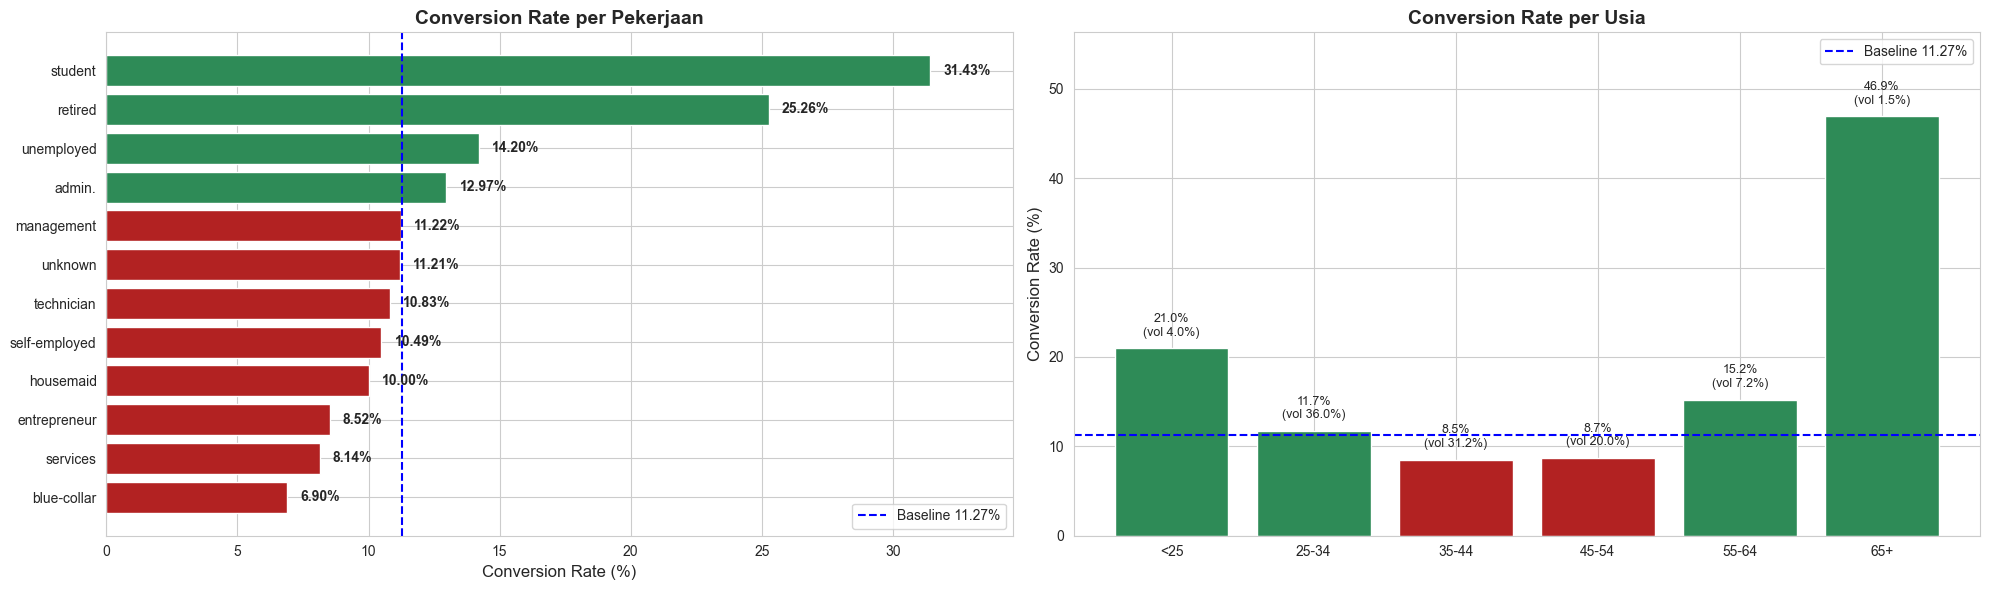

,count,sum,conv_rate,pct_volume,pct_deposan,lift
job,,,,,,
student,875,275,31.43,2.13,5.93,2.79
retired,1718,434,25.26,4.17,9.36,2.24
unemployed,1014,144,14.20,2.46,3.10,1.26
admin.,10419,1351,12.97,25.30,29.12,1.15
management,2924,328,11.22,7.10,7.07,1.00
unknown,330,37,11.21,0.80,0.80,1.00
technician,6739,730,10.83,16.37,15.74,0.96
self-employed,1421,149,10.49,3.45,3.21,0.93
housemaid,1060,106,10.00,2.57,2.28,0.89


,count,sum,conv_rate,pct_volume,pct_deposan,lift
age_group,,,,,,
<25,1665,349,20.96,4.04,7.52,1.86
25-34,14844,1740,11.72,36.05,37.51,1.04
35-44,12839,1092,8.51,31.18,23.54,0.76
45-54,8247,717,8.69,20.03,15.46,0.77
55-64,2963,451,15.22,7.20,9.72,1.35
65+,618,290,46.93,1.50,6.25,4.17


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

t = job_conv.sort_values('conv_rate')
axes[0].barh(t.index, t['conv_rate'], color=np.where(t['conv_rate'] >= baseline_rate, 'seagreen', 'firebrick'))
for i, v in enumerate(t['conv_rate']):
    axes[0].text(v + 0.5, i, f"{v:.2f}%", va='center', fontsize=10, weight="bold")
axes[0].axvline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[0].set_xlim(0, max(t['conv_rate'].max(), baseline_rate) * 1.1)
axes[0].set_title("Conversion Rate per Pekerjaan", fontsize=14, weight="bold")
axes[0].set_xlabel("Conversion Rate (%)", fontsize=12)
axes[0].legend()

t = age_conv
axes[1].bar(t.index.astype(str), t['conv_rate'], color=np.where(t['conv_rate'] >= baseline_rate, 'seagreen', 'firebrick'))
for i, (cr, pv) in enumerate(zip(t['conv_rate'], t['pct_volume'])):
    axes[1].text(i, cr + t['conv_rate'].max()*0.03, f'{cr:.1f}%\n(vol {pv:.1f}%)', ha='center', fontsize=9)
axes[1].set_ylim(0, max(t['conv_rate'].max(), baseline_rate) * 1.2)
axes[1].axhline(baseline_rate, color='blue', linestyle='--', label=f'Baseline {baseline_rate:.2f}%')
axes[1].set_title("Conversion Rate per Usia", fontsize=14, weight="bold")
axes[1].set_ylabel("Conversion Rate (%)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

display(job_conv.sort_values('conv_rate', ascending=False))
display(age_conv)

In [49]:
job_conv.sort_values('conv_rate', ascending=False).head(10)

,count,sum,conv_rate,pct_volume,pct_deposan,lift
job,,,,,,
student,875,275,31.43,2.13,5.93,2.79
retired,1718,434,25.26,4.17,9.36,2.24
unemployed,1014,144,14.20,2.46,3.10,1.26
admin.,10419,1351,12.97,25.30,29.12,1.15
management,2924,328,11.22,7.10,7.07,1.00
unknown,330,37,11.21,0.80,0.80,1.00
technician,6739,730,10.83,16.37,15.74,0.96
self-employed,1421,149,10.49,3.45,3.21,0.93
housemaid,1060,106,10.00,2.57,2.28,0.89


Sekarang kira masuk ke uji inferensial: Apakah selisih antar segmen nyata atau variasi sampel? Disini kita akan menggunakan two-proportion z-test, karena target `y` merupakan binary (yes or no), jadi yang dibandingkan adalah proporsi deposan, bukan rata-rata, sehingga t-test tidak tepat. Dua kelompok yang dibandingkan saling bebas, dan setiap kelompok berisi ratusan sampai belasan ribu nasabah sehingga syarat aproksimasi normal (n*p >= 10) terpenuhi dengan aman. Berikut adalah hipotesis untuk uji:
- H0: proporsi deposan kedua kelompok sama (p1 = p2)
- H1: proporsi deposan kedua kelompok berbeda (p1 != p2)

H0 ditolak bila p-value < 0.05 

In [60]:
# Pelajar + pensiunan vs blue-collar
g1 = df_clean.loc[df_clean['job'].isin(['student', 'retired']), 'y']
g2 = df_clean.loc[df_clean['job'] == 'blue-collar', 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)                          # proporsi gabungan (pooled)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Pelajar + pensiunan ({p1*100:.2f}%, n={n1:,}) vs Blue-collar ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

# Usia > 60 tahun vs usia 35-44 tahun
g1 = df_clean.loc[df_clean['age'] > 60, 'y']
g2 = df_clean.loc[df_clean['age'].between(35, 44), 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Usia > 60 tahun ({p1*100:.2f}%, n={n1:,}) vs Usia 35-44 tahun ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

# Status kredit tidak diketahui vs diketahui
g1 = df_clean.loc[df_clean['default'] == 'unknown', 'y']
g2 = df_clean.loc[df_clean['default'] == 'no', 'y']
n1, n2 = len(g1), len(g2)
p1, p2 = g1.mean(), g2.mean()
p_gab  = (g1.sum() + g2.sum()) / (n1 + n2)
z      = (p1 - p2) / np.sqrt(p_gab * (1 - p_gab) * (1/n1 + 1/n2))
p_val  = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"default = 'unknown' ({p1*100:.2f}%, n={n1:,}) vs default = 'no' ({p2*100:.2f}%, n={n2:,})")
print(f"  selisih = {(p1-p2)*100:+.2f} poin persentase | z = {z:.2f} | p-value = {p_val:.3e}"
      f" | {'SIGNIFIKAN' if p_val < 0.05 else 'tidak signifikan'} pada alpha 5%\n")

Pelajar + pensiunan (27.34%, n=2,593) vs Blue-collar (6.90%, n=9,253)
  selisih = +20.45 poin persentase | z = 28.99 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%

Usia > 60 tahun (45.54%, n=909) vs Usia 35-44 tahun (8.66%, n=13,495)
  selisih = +36.89 poin persentase | z = 34.43 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%

default = 'unknown' (5.15%, n=8,596) vs default = 'no' (12.88%, n=32,577)
  selisih = -7.73 poin persentase | z = -20.15 | p-value = 0.000e+00 | SIGNIFIKAN pada alpha 5%



Hasilnya, ketiga perbandingan di atas signifikan, di mana pelajar + pensiunan mengungguli blue-collar, usia > 60 mengungguli usia 36–45, dan status kredit `unknown` tertinggal dari `no`.

Tetapi ada satu keterbatasan penting: kelompok-kelompok tersebut dibentuk oleh analis, bukan dari data. Garis potong "usia > 60" dan "usia 36-45" dipilih setelah melihat grafik. Uji proporsi baru bisa bekerja setelah garis potongnya ditetapkan, ia tidak dapat menjawab apakah usia itu sendiri, sebagai angka mentah tanpa dikelompokkan, membedakan deposan dari nono-deposan.

Pertanyaan itu butuh jenis uji yang berbeda dan inilah alasan peralihannya:
- Yang dibandingkan bukan proporsi lagi, melaiknkan sebaran angka. Bukan "berapa persen yang berdeposito di tiap kelompok", tetapi "apakah usia deposan cenderung berbeda dari usia non-deposan"
- Kenapa Mann-Whitney U, bukan t-test? t-test mensyaratkan data berdistribusi normal, sedangkan QQ-plot di section C menunjukkan `age` menceng kee kanan. Mann-Whitney membandingkan peringkat, sehingga asumsi normalitas tidak diperlukan.
- Hasil analisa yang akan dilakukan setelah ini sangat menentukan. Bila usia berhubungan secara monotonik (makin tua konversi makin tinggi, dan sebaliknya), `age` boleh dipakai langsung sebagai angka. Bila tidak, `age` wajib dikelompokkan. Grafik deskriptif tadi memperlihatkan pola berbentuk U, uji berikut yang membuktikannya secara statistik.


Berikut adalah hipotesis dari uji Mann-Whitney:
- H0: sebaran usia deposan = sebaran usia non-deposan
- H1: sebaran usia deposan != sebaran usia non-deposan 

H0 ditolak bila p-value < 0,05.

In [62]:
usia_deposan     = df_clean.loc[df_clean.y == 1, 'age']
usia_non_deposan = df_clean.loc[df_clean.y == 0, 'age']
u, p_val = stats.mannwhitneyu(usia_deposan, usia_non_deposan, alternative='two-sided')
rank_biserial = (2 * u) / (len(usia_deposan) * len(usia_non_deposan)) - 1   # ukuran besar efek

print('--- Mann-Whitney U pada `age` sebagai variabel kontinu (alpha = 5%) ---')
print(f"median usia deposan = {usia_deposan.median():.0f} th | "
      f"median usia non-deposan = {usia_non_deposan.median():.0f} th")
print(f"U = {u:,.0f} | p-value = {p_val:.3e} | rank-biserial = {rank_biserial:+.3f}")
print(f"  -> H0 ditolak pada alpha 5% (p = {p_val:.4f}), TETAPI rank-biserial {rank_biserial:+.3f}")
print("     menunjukkan besar efeknya nyaris nol, usia tidak berhubungan secara MONOTONIK.")
print("     Kesimpulan: `age` wajib dikelompokkan (binning), bukan dipakai sebagai angka mentah.")

--- Mann-Whitney U pada `age` sebagai variabel kontinu (alpha = 5%) ---
median usia deposan = 37 th | median usia non-deposan = 38 th
U = 82,905,028 | p-value = 1.564e-02 | rank-biserial = -0.022
  -> H0 ditolak pada alpha 5% (p = 0.0156), TETAPI rank-biserial -0.022
     menunjukkan besar efeknya nyaris nol, usia tidak berhubungan secara MONOTONIK.
     Kesimpulan: `age` wajib dikelompokkan (binning), bukan dipakai sebagai angka mentah.


**INSIGHT AKHIR**

Pelajar (31,43%) dan pensiunan (25,26%) memiliki conversion rate 2,79x dan 2,24x baseline, sedangkan blue-collar hanya 6,90% (lift 0,61x). Selisih pelajar + pensiunan terhadap blue-collar sebesar +20,45 poin persentase dan signifikan secara statistik (z = 28,99; p < 0,001), sehingga perbedaan ini bukan sekadar variasi sampel.

Dua kelompok paling produktif itu hanya menerima 6,3% panggilan (875 + 1.718 kontak), sementara blue-collar dan admin menyerap 47,8% panggilan (22,47% + 25,30%). Kapasitas telemarketing terbesar justru diarahkan ke segmen dengan hasil paling rendah.

Hubungan usia dengan konversi berbentuk U, bukan garis lurus. Konversi tertinggi ada pada kelompok usia tertua (46,93%, lift 4,17x) yang hanya menyerap 1,50% panggilan, disusul kelompok termuda (20,96%) dan kelompok 55-64 (15,22%). Titik terendahnya justru di kelompok 35-44 (8,51%) dan 45-54 8,69 — dua kelompok yang bersama-sama menyerap 51,21% seluruh panggilan. Perbandingan langsung nasabah usia > 60 tahun (45,54%) dengan usia 35-44 tahun (8,66%) memberi selisih +36,89 poin persentase (z = 34,43; p < 0,001).

Uji Mann-Whitney juga menegaskan bentuk U tersebut. Pada `age` sebagai variabel kontinu, rank-biserial hanya -0,022, nyaris nol, meskipun p-value-nya lolos alpha 5% (p = 0,0156). Uji monotonik memang tidak dirancang untuk menangkap hubungan berbentuk U: nasabah muda dan nasabah tua sama-sama berkonversi tinggi sehingga saling meniadakan ketika dibandingkan sebagai peringkat. Kesimpulannya, `age` wajib diperlakukan sebagai kelompok (binning), bukan sebagai variabel numerik linear. Lolosnya ambang 5% tidak berarti apa-apa ketika ukuran efeknya praktis nol.

Nasabah dengan `default = 'unknown'` hanya berkonversi 5,15%, sementara `default = 'no'` mencapai 12,88%. Selisih -7,73 poin persentase ini signifikan kuat (z = -20,15; p < 0,001) dan mencakup 20,88% populasi (8.596 dari 41.176 nasabah). Ketidaksediaan nasabah mengungkap status kreditnya ternyata merupakan sinyal negatif yang nyata, bukan derau. Inilah yang membenarkan keputusan mempertahankan `unknown` sebagai kategori tersendiri pada tahap preprocessing: bila diimputasi dengan modus `'no'`, 8.596 nasabah berkonversi rendah akan dilebur ke kelompok berkonversi tinggi dan sinyal senilai 7,73 poin persentase hilang begitu saja.

Pola U ini sejalan dengan *life-cycle hypothesis* (Modigliani): kelompok usia pensiun memegang akumulasi kekayaan terbesar dan bergeser ke instrumen berisiko rendah, sedangkan usia 35-54 berada pada puncak beban konsumsi (cicilan rumah, biaya pendidikan anak) sehingga dana menganggurnya paling kecil.

**Rekomendasi**

Susun *call list* harian dengan kuota minimum untuk segmen pensiunan (usia > 60) dan pelajar; turunkan porsi blue-collar usia 35-54 yang saat ini mendominasi antrean. Tempatkan nasabah berstatus kredit `unknown` pada prioritas terendah, atau verifikasi datanya lebih dulu oleh tim data sebelum masuk antrean panggilan.

**Estimasi dampak**

Setiap 1.000 panggilan yang dialihkan dari profil usia 35-44 tahun (8,66%) ke profil usia > 60 tahun (45,54%) berpotensi menambah ±369 deposan tanpa menambah kapasitas (selisih 36,89 pp).

> NOTE: Segmen usia > 60 pada kampanye ini hanya berisi 909 nasabah dan seluruhnya sudah dihubungi, sehingga realokasi hanya mungkin bila basis nasabah bank masih menyimpan nasabah lansia yang belum tersentuh. Angka di atas adalah potensi per 1.000 panggilan, bukan total yang dijamin tercapai.

### d. Kapan waktu terbaik untuk menghubungi nasabah?